<a href="https://www.kaggle.com/code/lalit7881/heart-disease-risk-2026-eda-88?scriptVersionId=336627162" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Import essential libraries and configure settings
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings to keep output neat

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # ensure Agg backend is used

import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # for inline rendering in some environments
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

from pathlib import Path

# Define helper to resolve file path
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Setup complete. Let the analysis begin...')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Setup complete. Let the analysis begin...
/kaggle/input/datasets/uditjain13/heart-disease-risk-2026/heart_disease_risk_2026.csv


## Loading dataset

In [2]:
# Resolve the file path dynamically
data_file = resolve_data_file(file_name='heart_disease_risk_2026.csv', suffixes=['.csv'])

# Load the dataset
df = pd.read_csv(data_file, delimiter=',', encoding='ascii')
print('Data loaded successfully with shape:', df.shape)

Data loaded successfully with shape: (9000, 27)


In [3]:
df.head()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [4]:
df.tail()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
8995,8996,36,Female,108,63,178,68,82,158,96,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,Female,112,73,213,54,139,102,125,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,Female,144,93,198,66,113,79,102,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,Female,130,70,220,68,135,109,104,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1
8999,9000,63,Female,152,104,215,64,117,109,120,...,False,Never,7.3,95,8.8,54.1,False,3860,54.5,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [6]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [7]:
df.isnull()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

patient_id                     int64
age                            int64
sex                           object
resting_bp_systolic            int64
resting_bp_diastolic           int64
cholesterol_total              int64
hdl                            int64
ldl                            int64
triglycerides                  int64
fasting_blood_sugar            int64
hba1c                        float64
bmi                          float64
resting_heart_rate             int64
max_heart_rate_achieved        int64
chest_pain_type               object
exercise_induced_angina         bool
st_depression                float64
family_history                  bool
smoker_status                 object
alcohol_units_per_week       float64
exercise_minutes_per_week      int64
sleep_hours                  float64
stress_score                 float64
wearable_owner                  bool
daily_steps                    int64
diet_quality_score           float64
has_heart_disease              int64
d

In [11]:
df.shape

(9000, 27)

In [12]:
df.columns

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='object')

In [13]:
df.nunique()

patient_id                   9000
age                            73
sex                             2
resting_bp_systolic            93
resting_bp_diastolic           71
cholesterol_total             200
hdl                            81
ldl                           163
triglycerides                 281
fasting_blood_sugar           136
hba1c                          45
bmi                           241
resting_heart_rate             60
max_heart_rate_achieved       115
chest_pain_type                 4
exercise_induced_angina         2
st_depression                  63
family_history                  2
smoker_status                   3
alcohol_units_per_week        308
exercise_minutes_per_week     332
sleep_hours                    77
stress_score                  860
wearable_owner                  2
daily_steps                  5414
diet_quality_score            763
has_heart_disease               2
dtype: int64

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64


Duplicate Rows : 0

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
patient_id,9000.0,4500.500000,2598.220545,1.0,2250.75,4500.5,6750.25,9000.0
age,9000.0,53.977333,13.008051,18.0,45.00,54.0,63.00,90.0
resting_bp_systolic,9000.0,127.849778,13.767233,85.0,119.00,128.0,137.00,181.0
resting_bp_diastolic,9000.0,80.788778,10.939943,50.0,74.00,81.0,88.00,126.0
cholesterol_total,9000.0,188.753556,32.271644,90.0,167.00,189.0,211.00,314.0
hdl,9000.0,55.215333,12.394400,18.0,47.00,55.0,64.00,110.0
ldl,9000.0,103.275556,27.342198,35.0,85.00,103.0,122.00,207.0
triglycerides,9000.0,152.045000,51.448384,35.0,117.00,151.0,186.00,390.0
fasting_blood_sugar,9000.0,119.470444,22.778082,60.0,104.00,119.0,135.00,204.0
hba1c,9000.0,5.791633,0.692645,4.0,5.30,5.8,6.30,8.6


['patient_id', 'age', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate', 'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours', 'stress_score', 'daily_steps', 'diet_quality_score', 'has_heart_disease']
['sex', 'chest_pain_type', 'smoker_status']


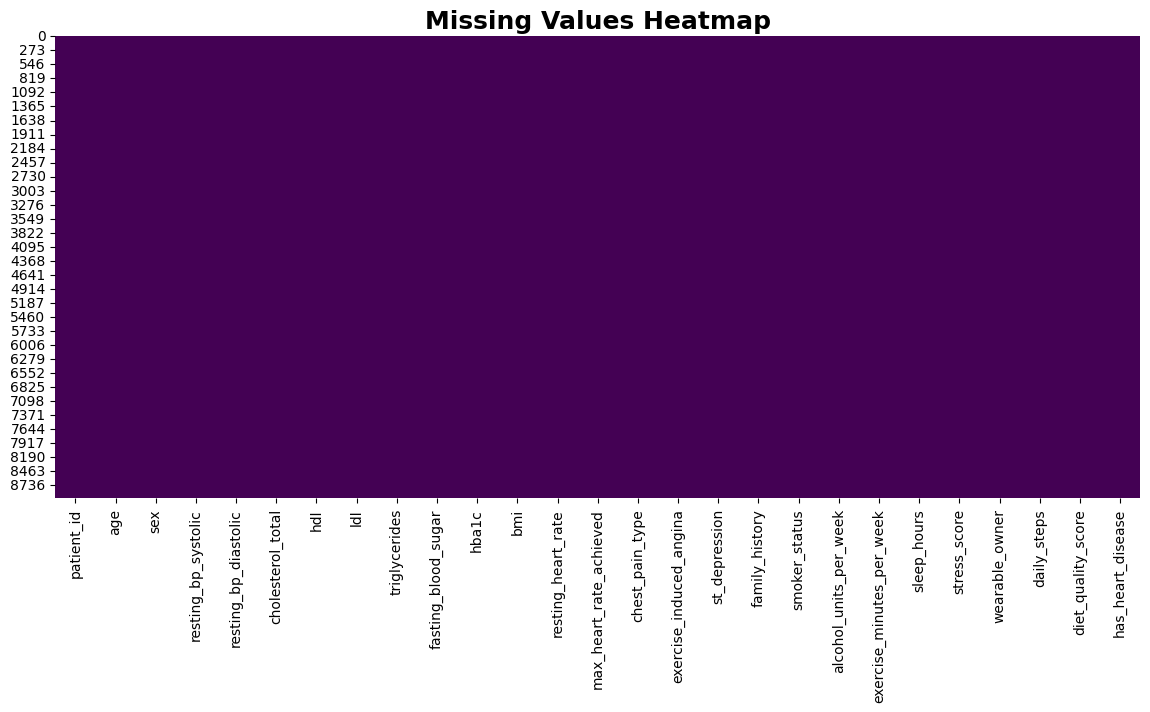

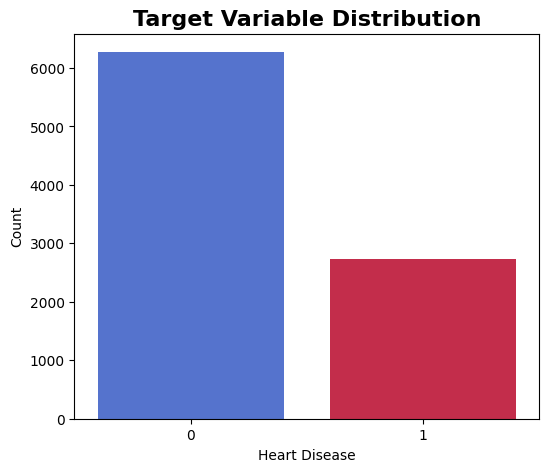

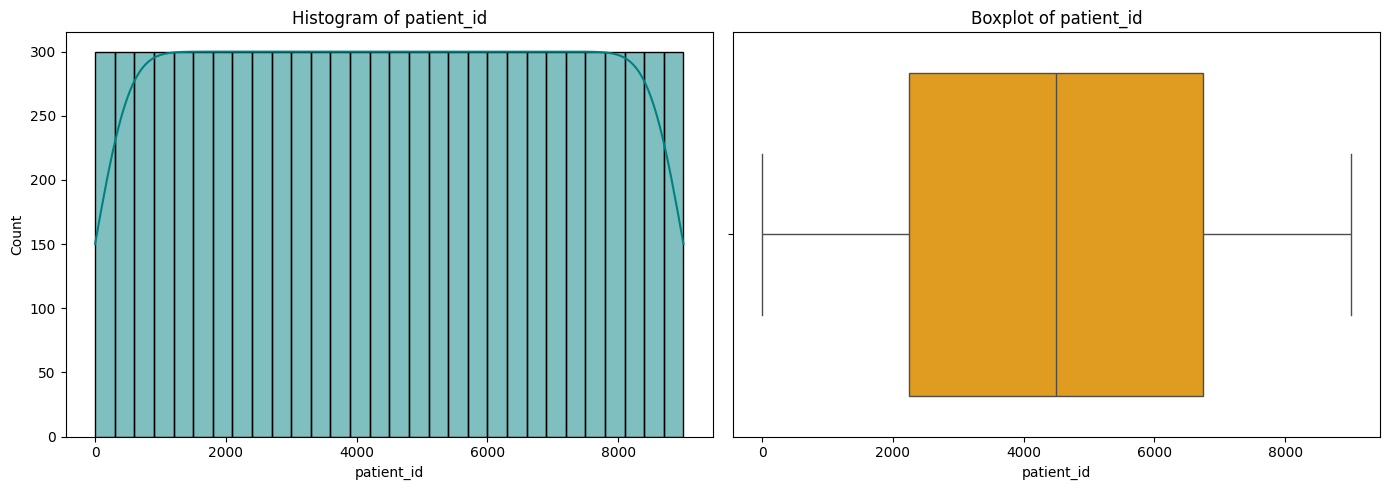

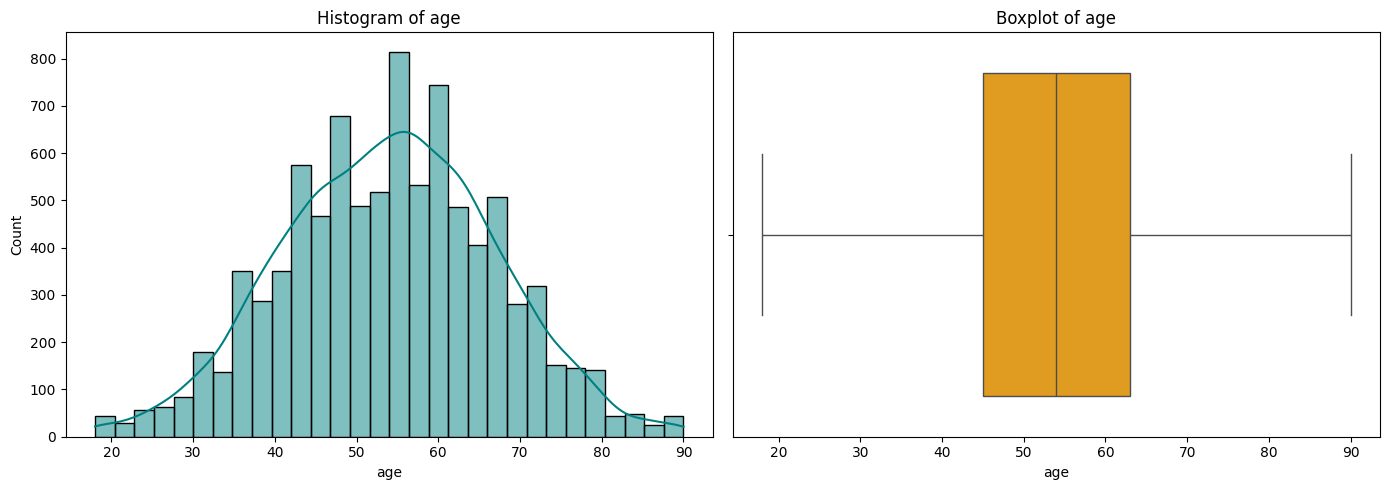

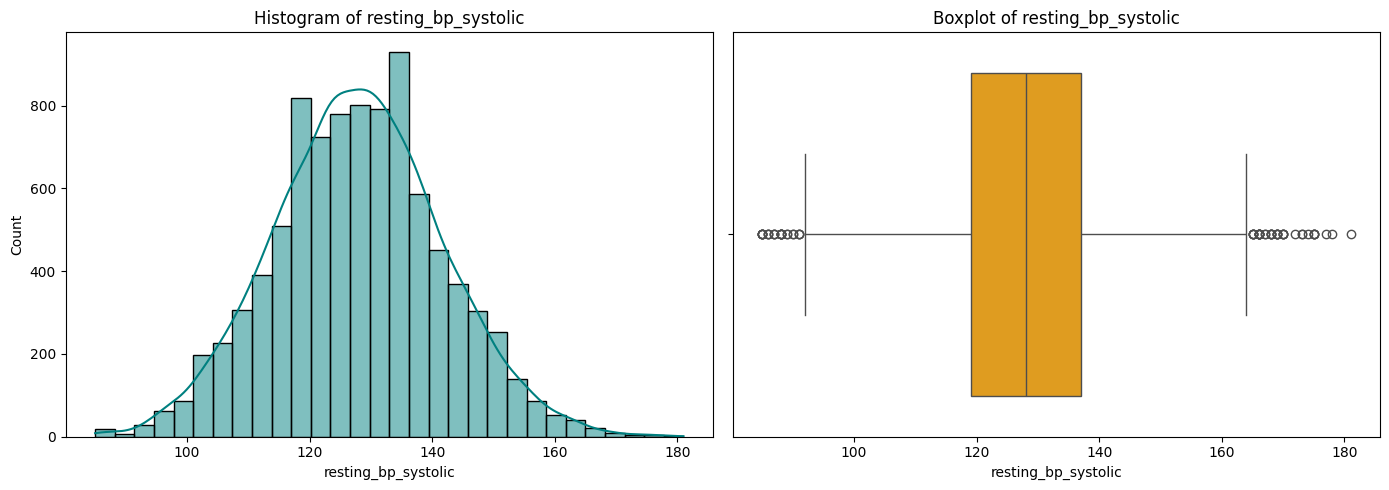

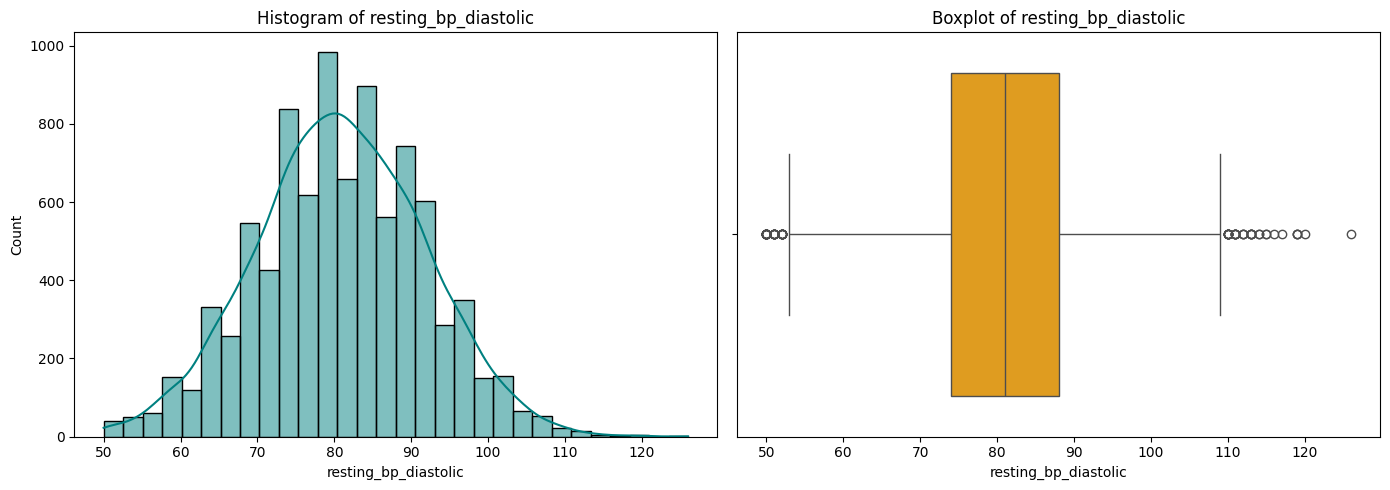

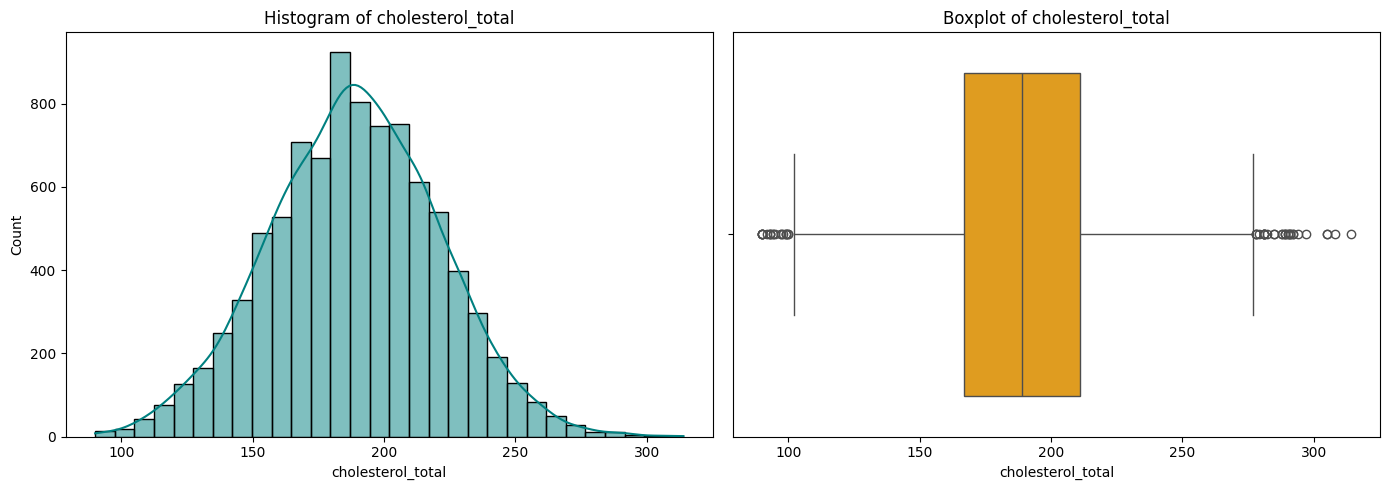

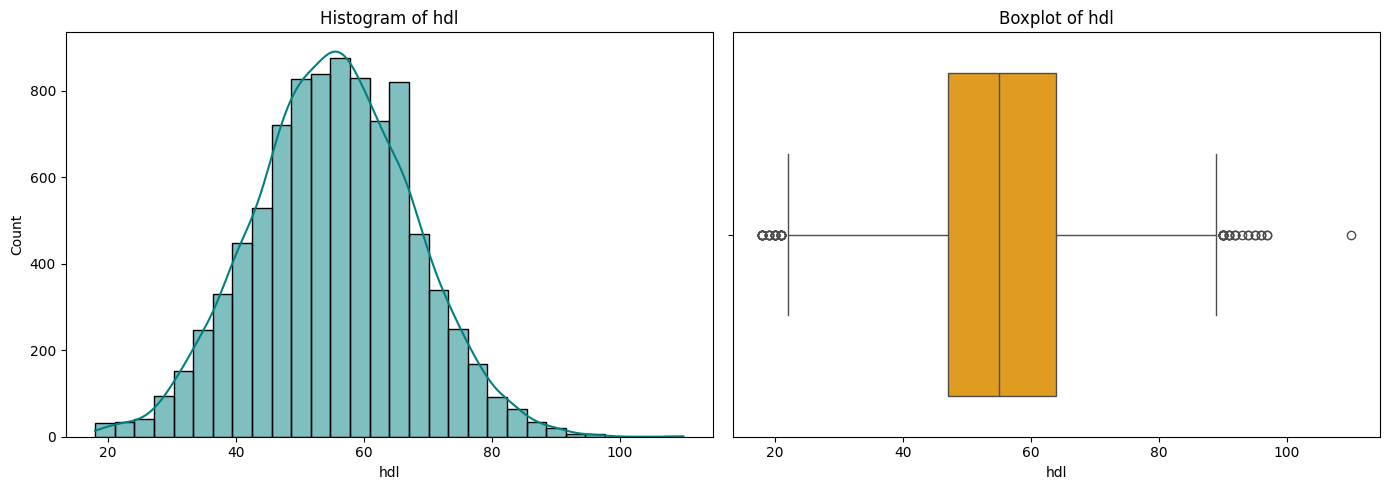

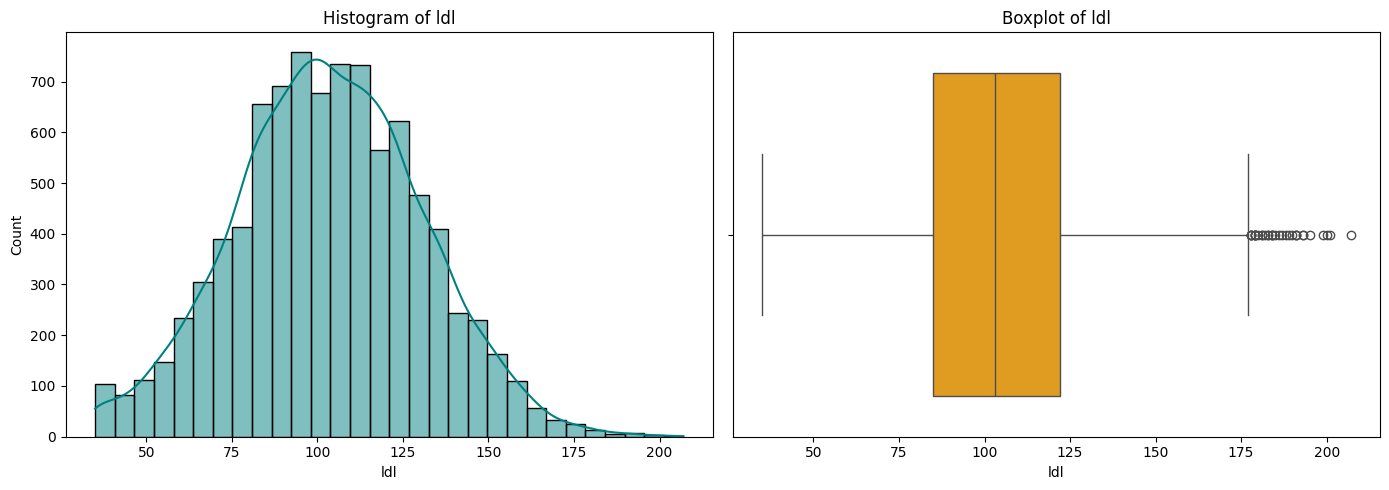

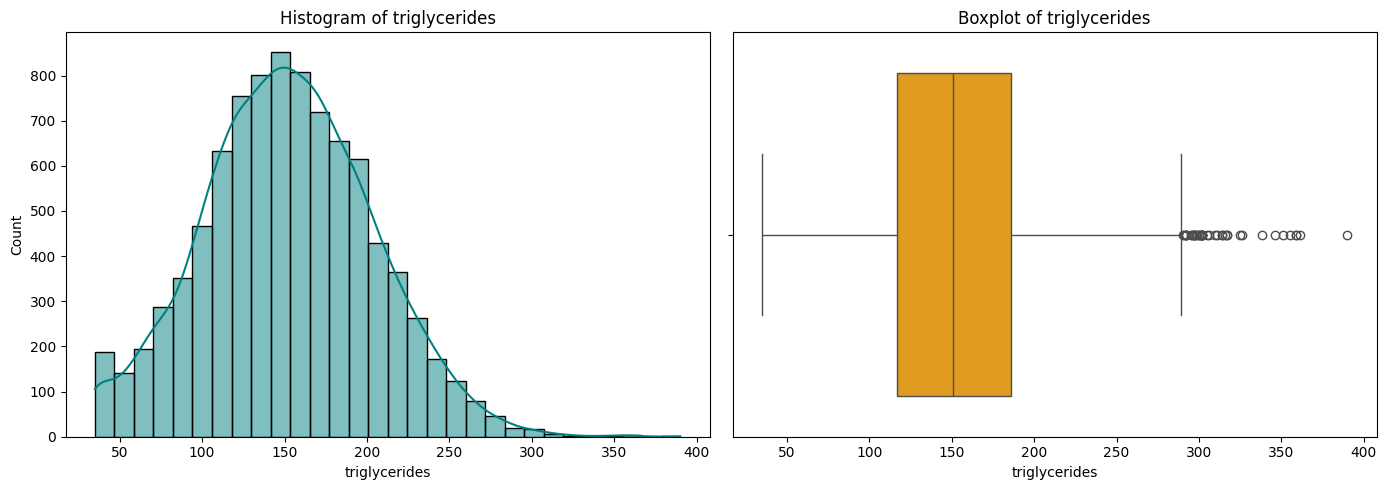

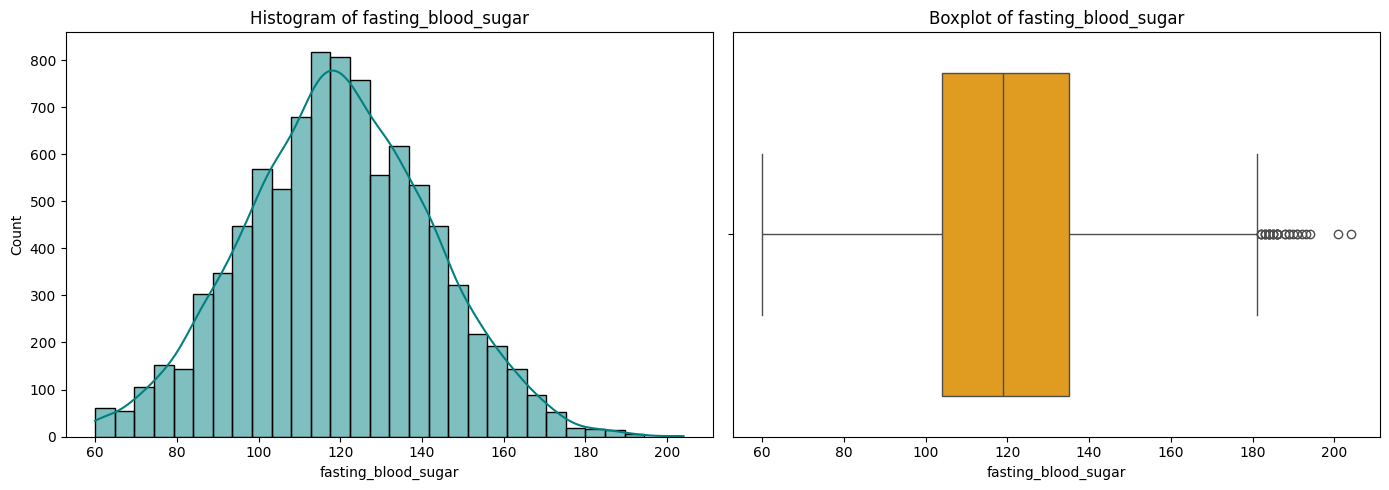

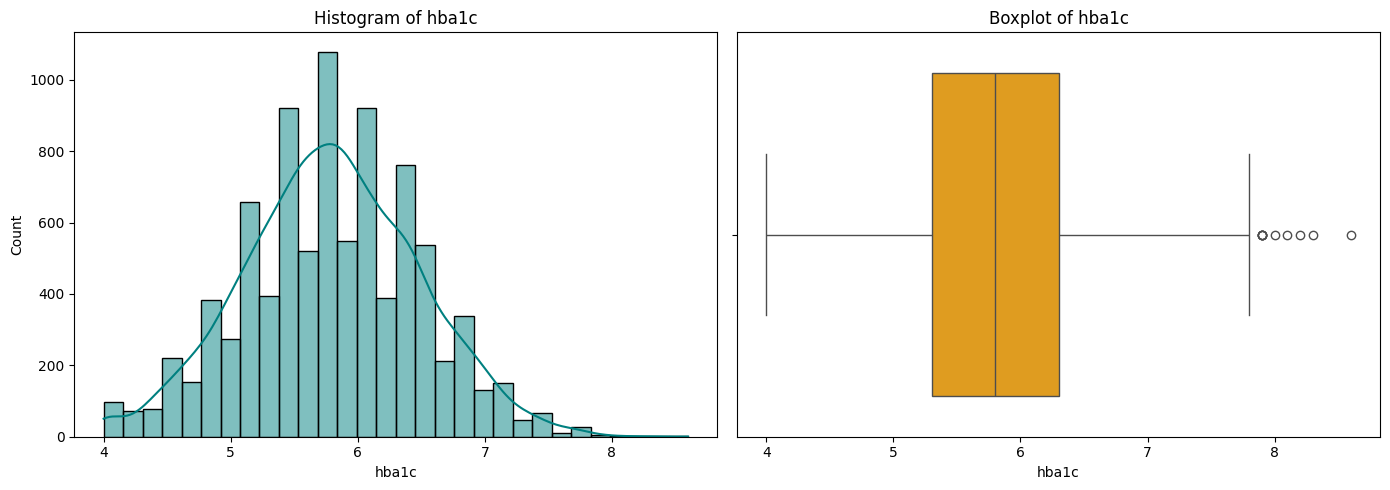

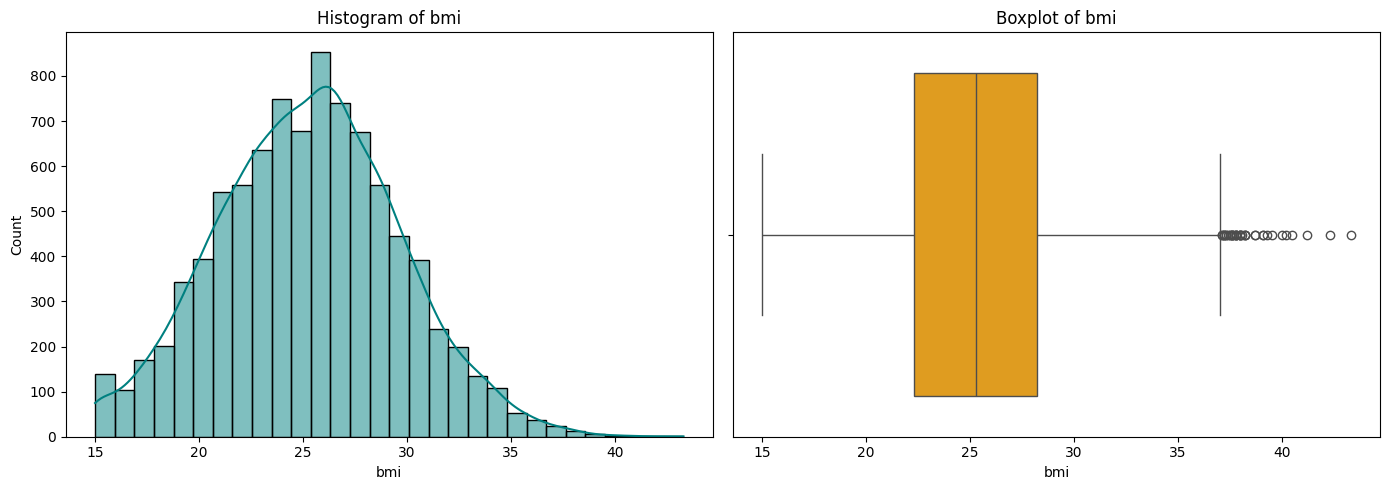

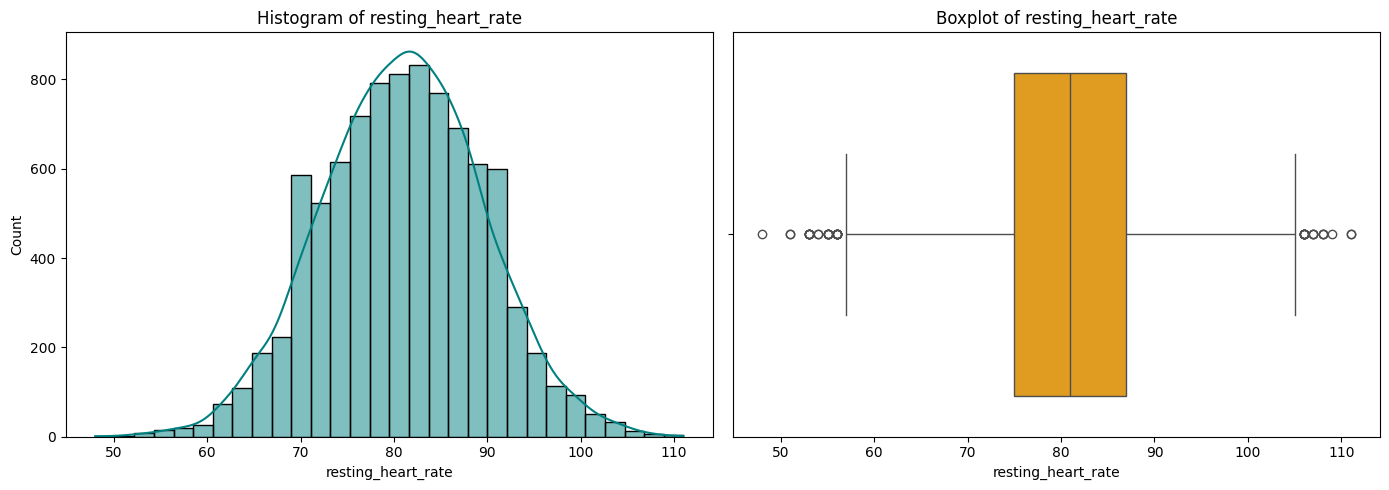

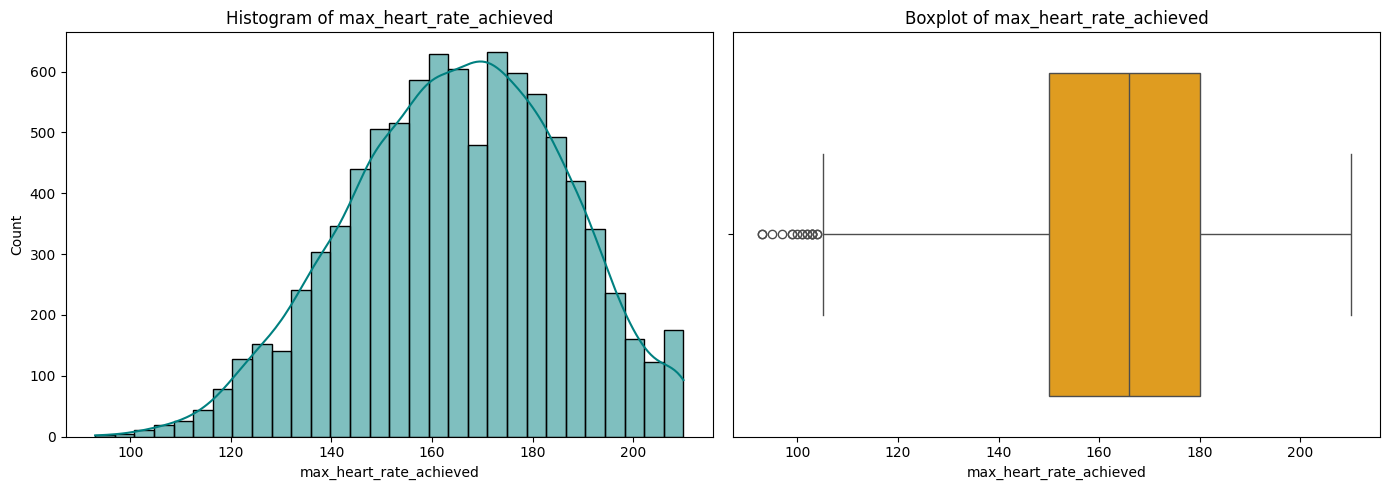

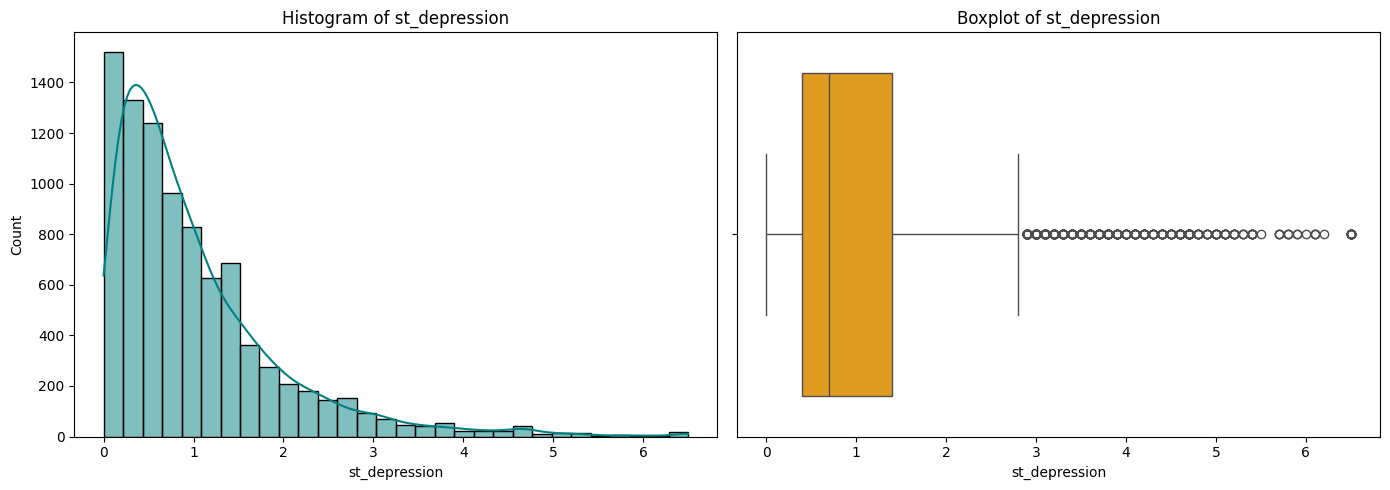

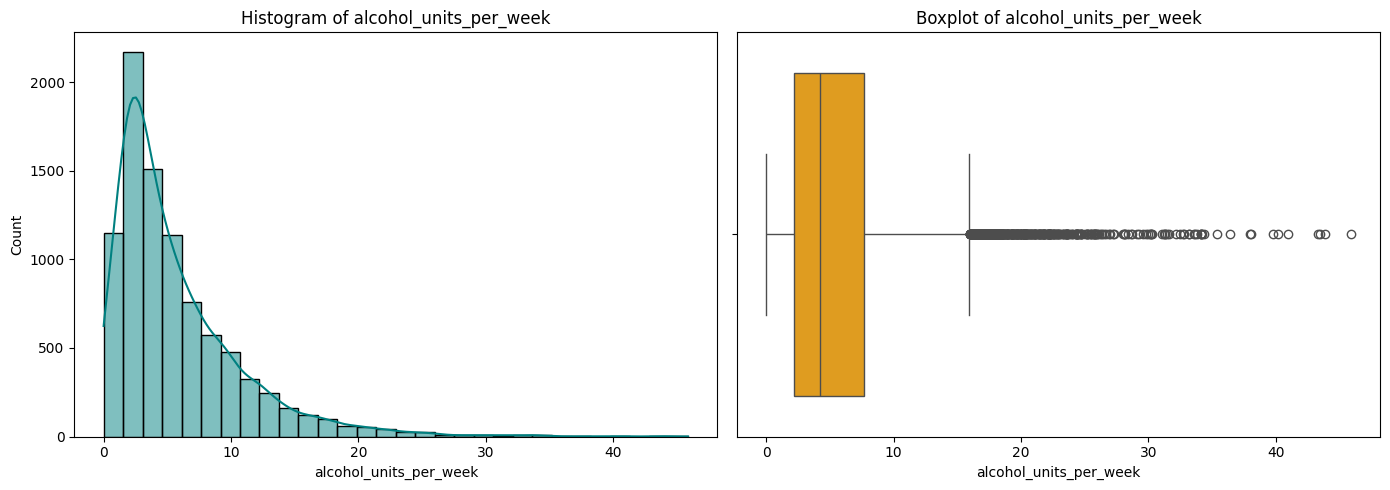

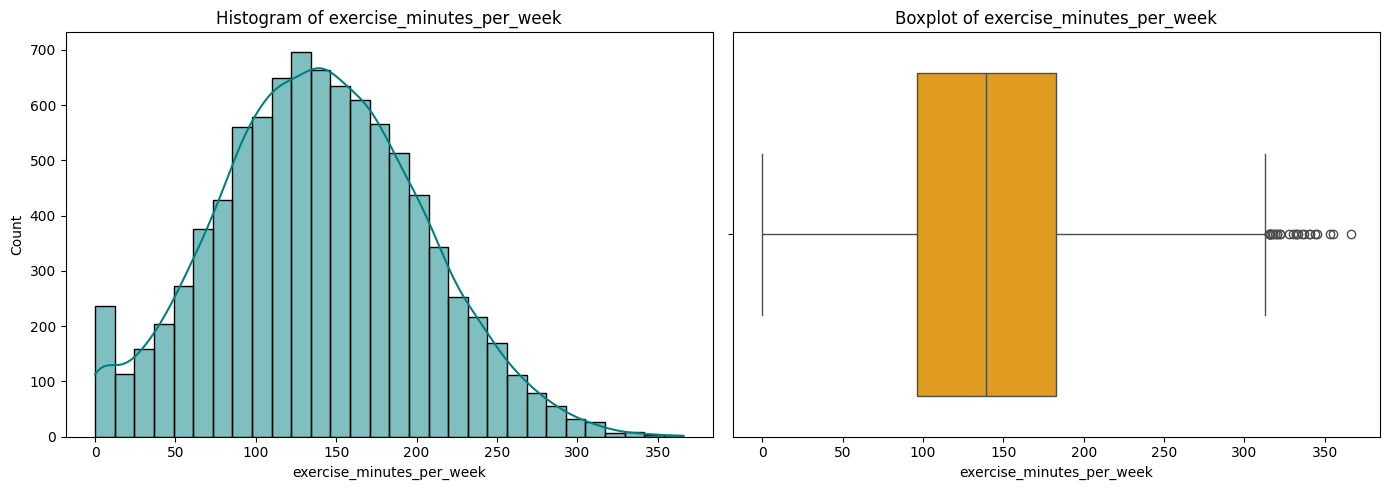

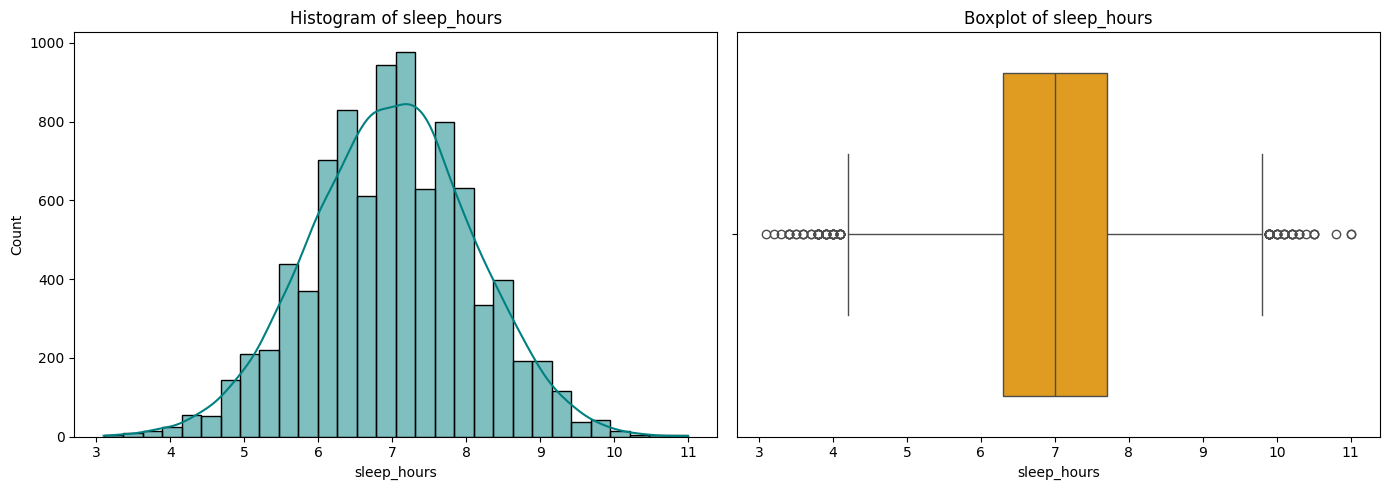

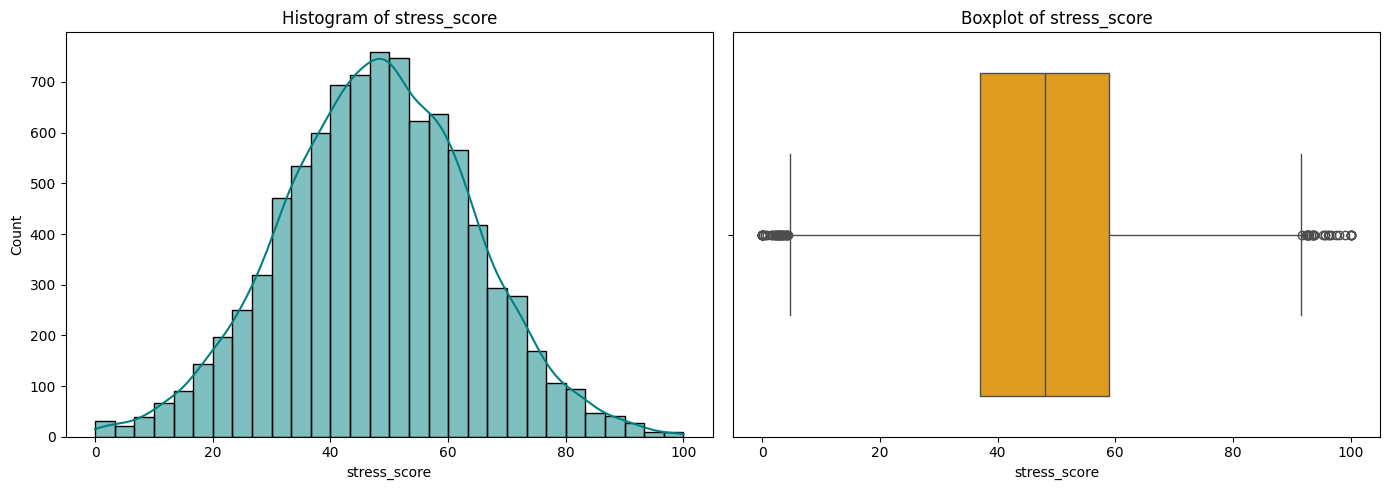

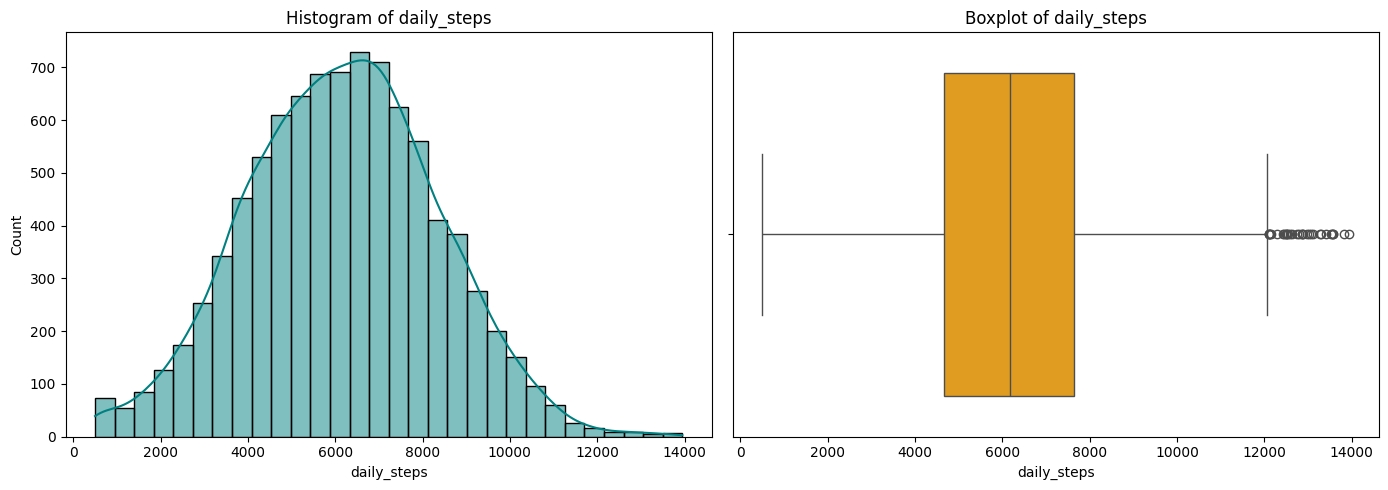

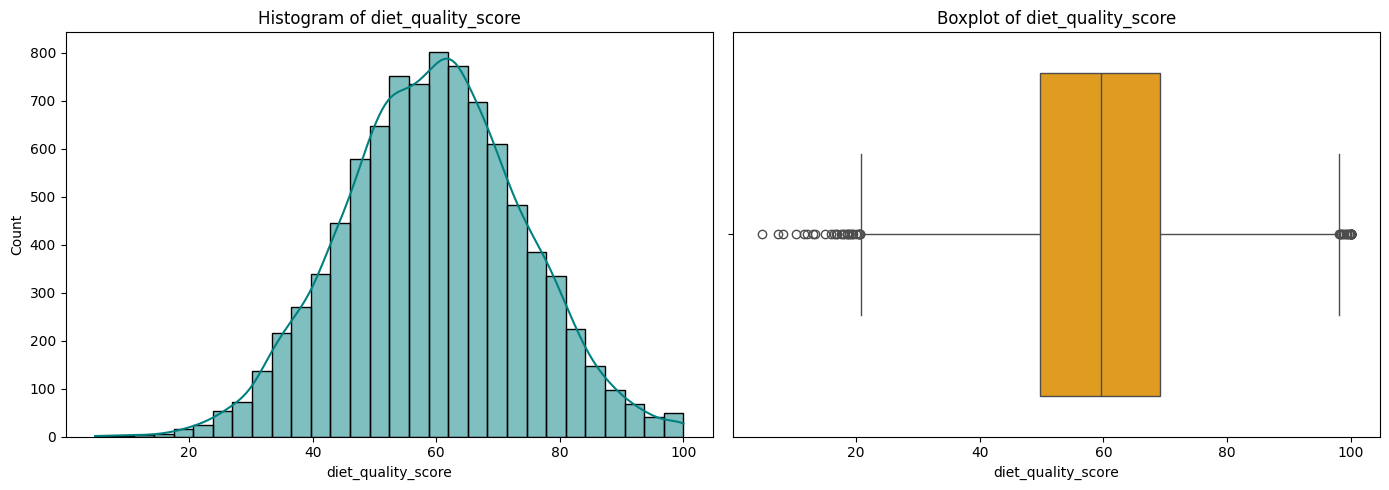

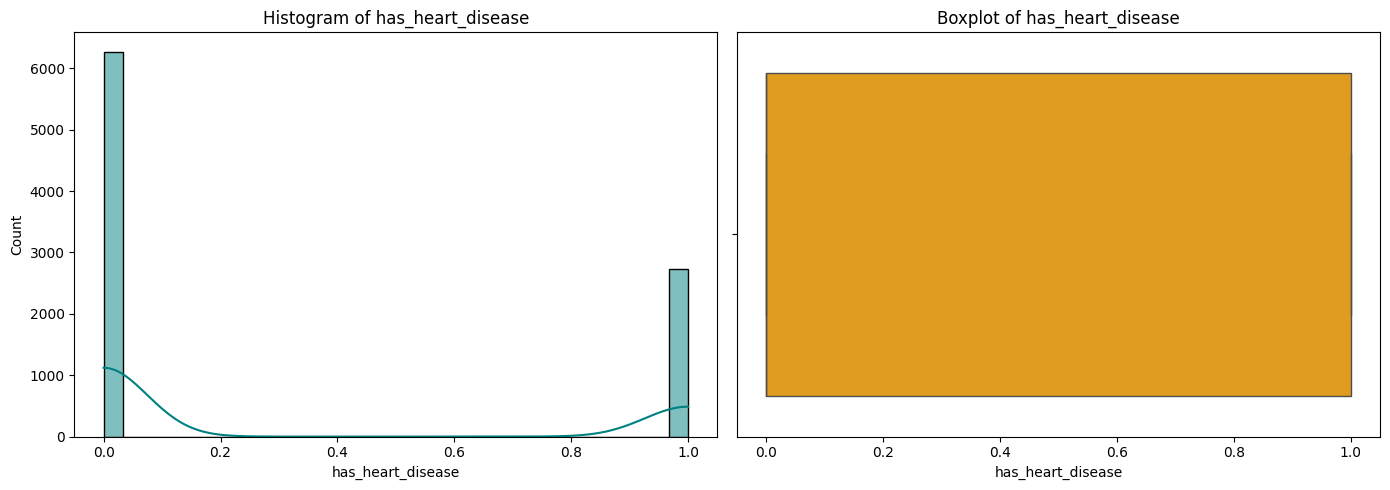

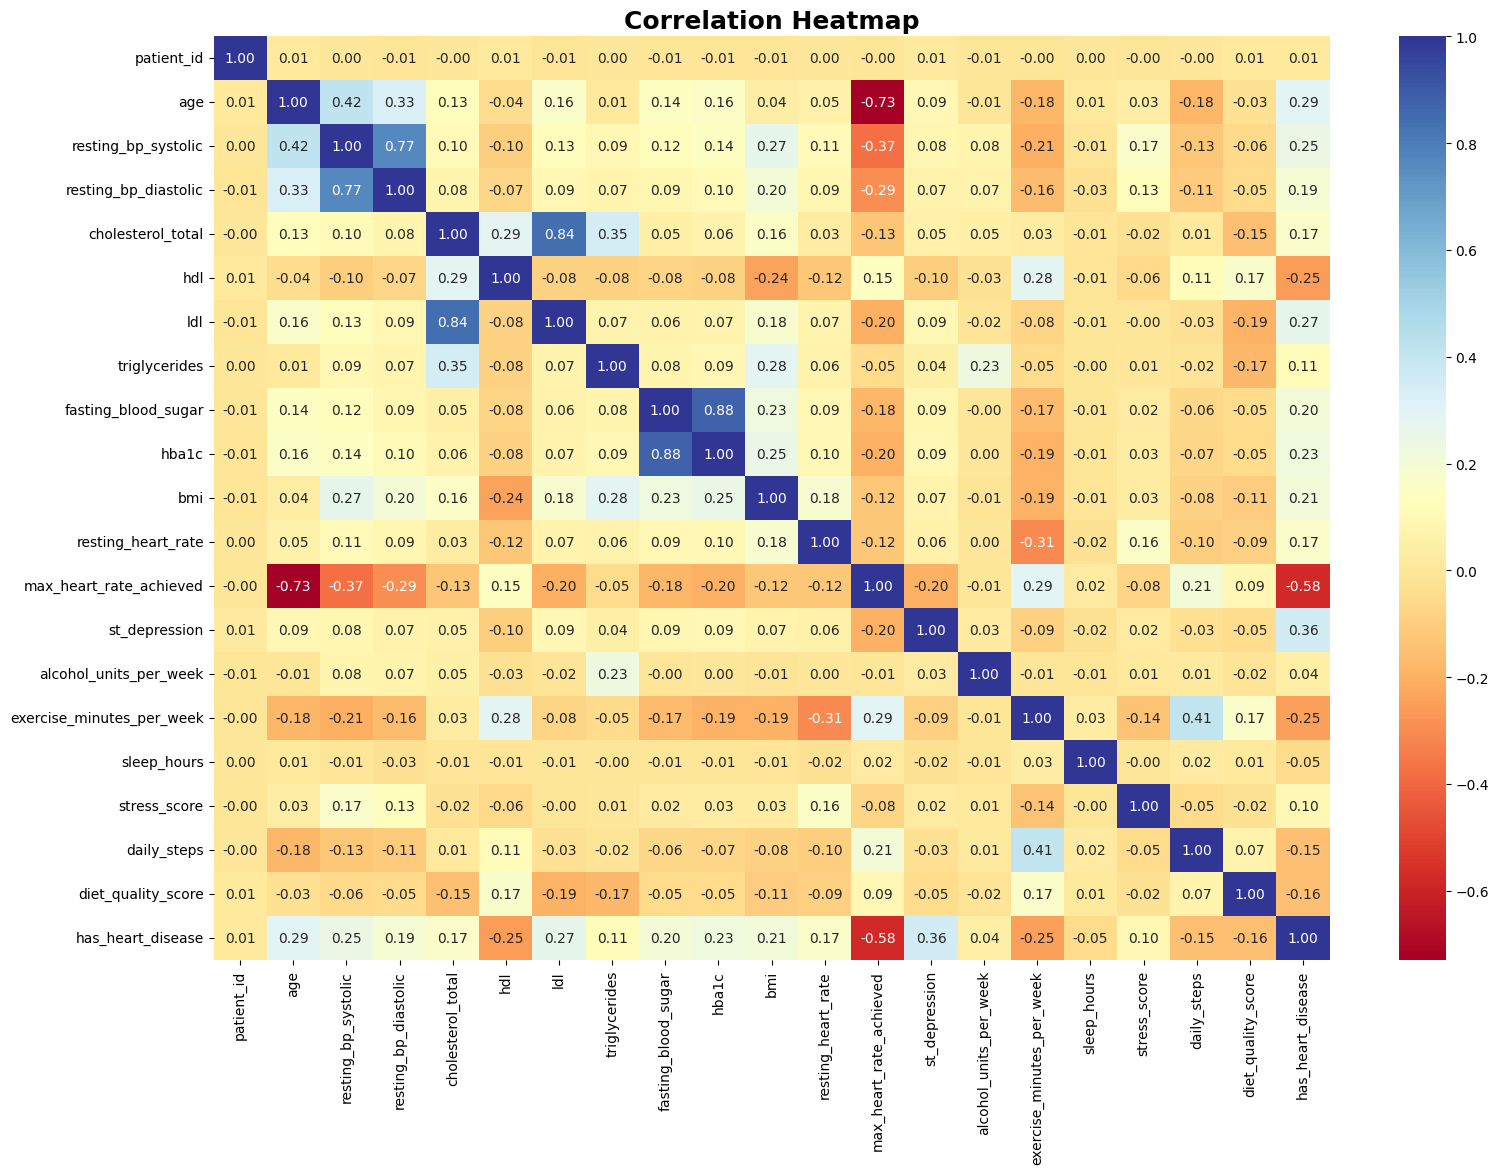

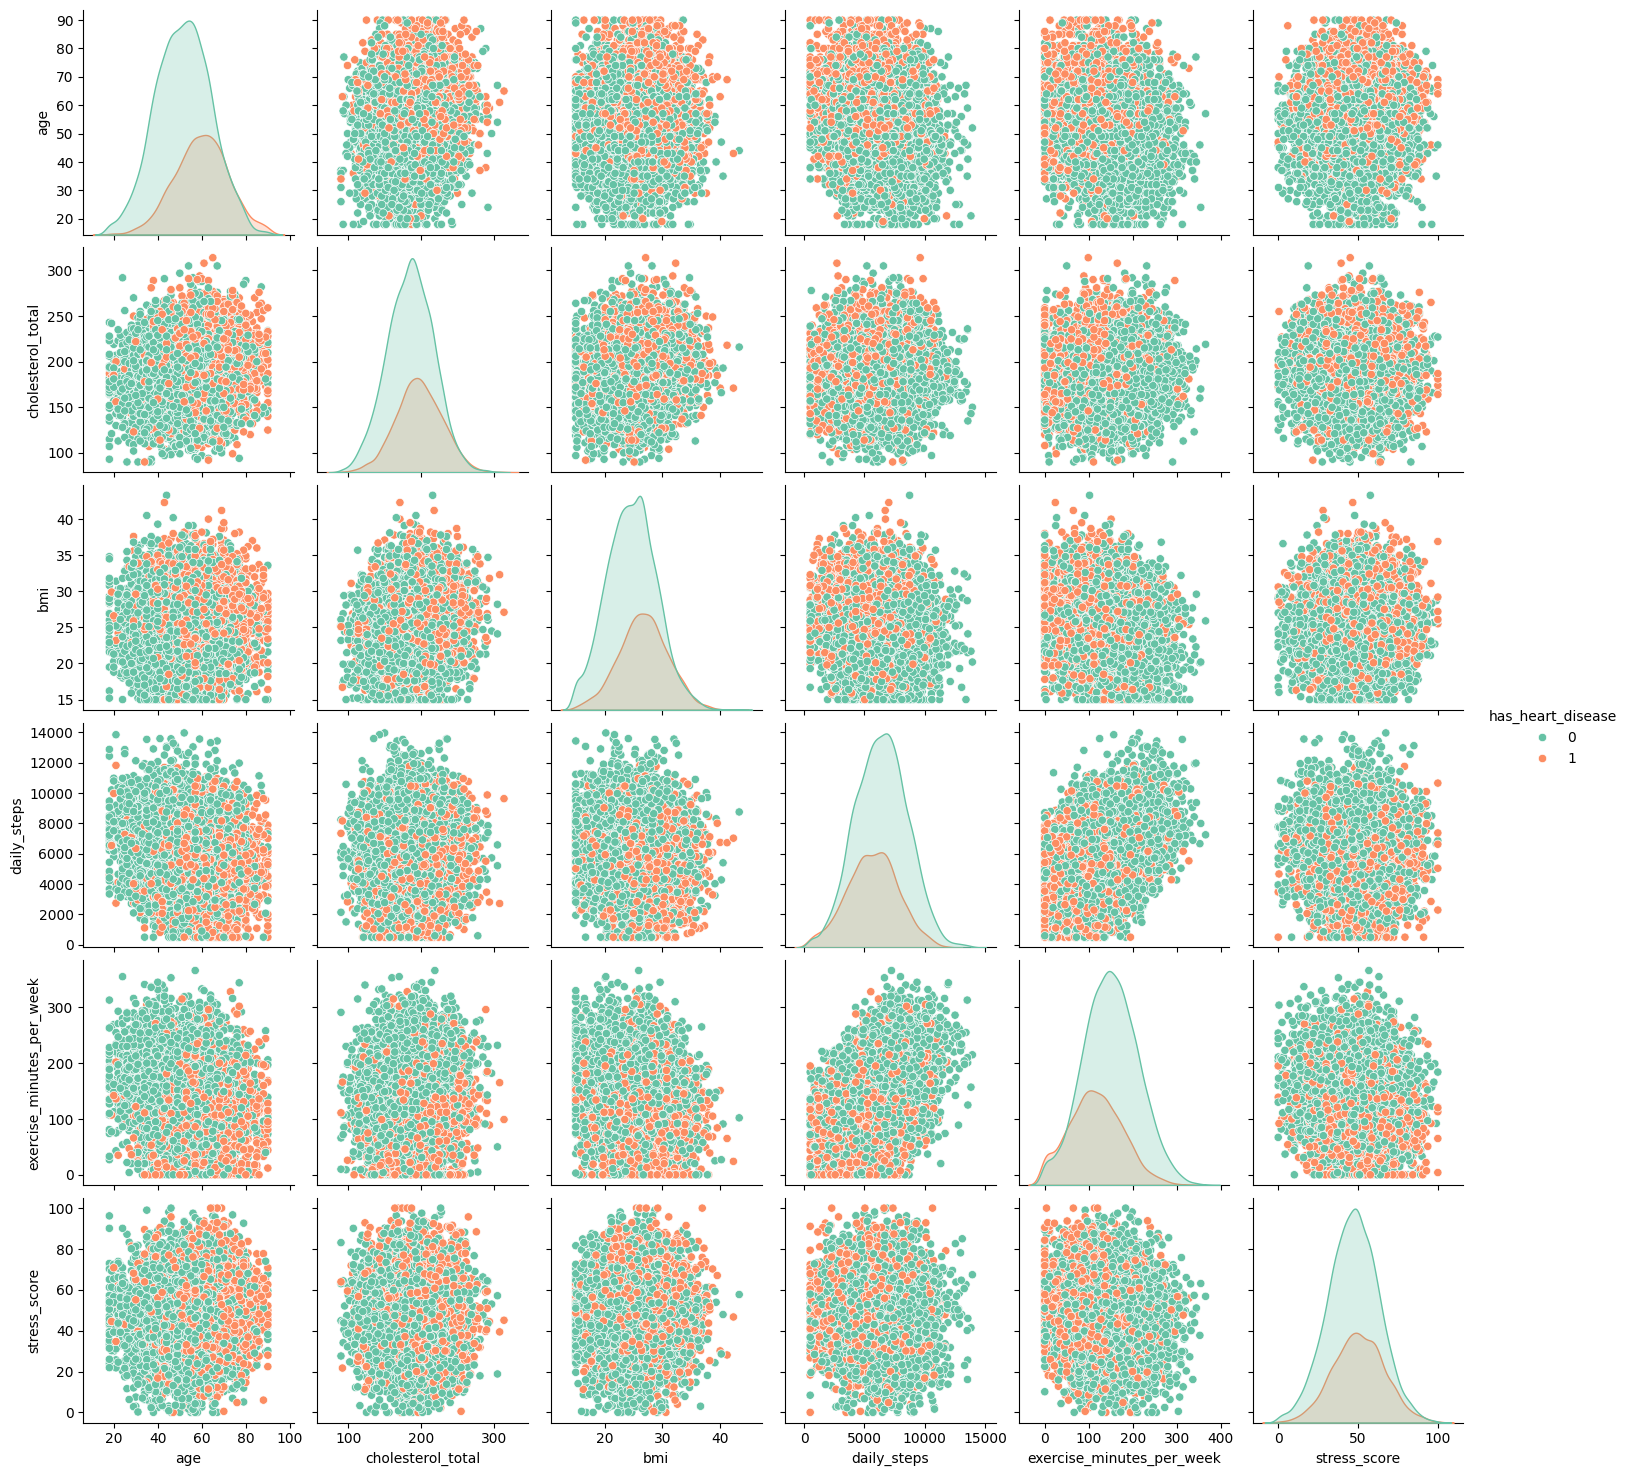

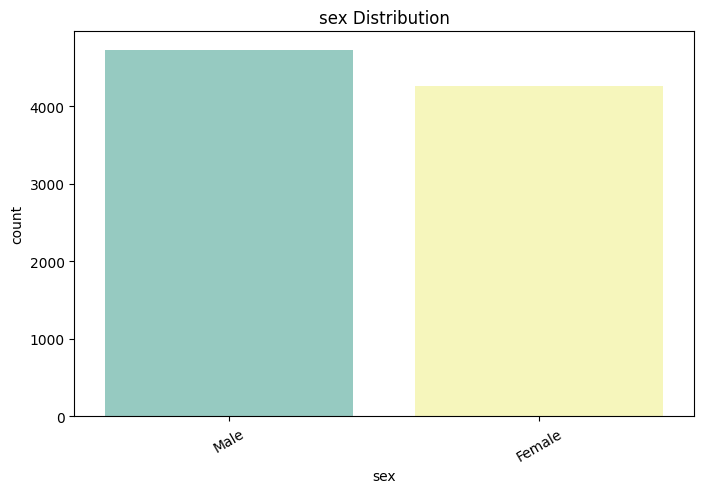

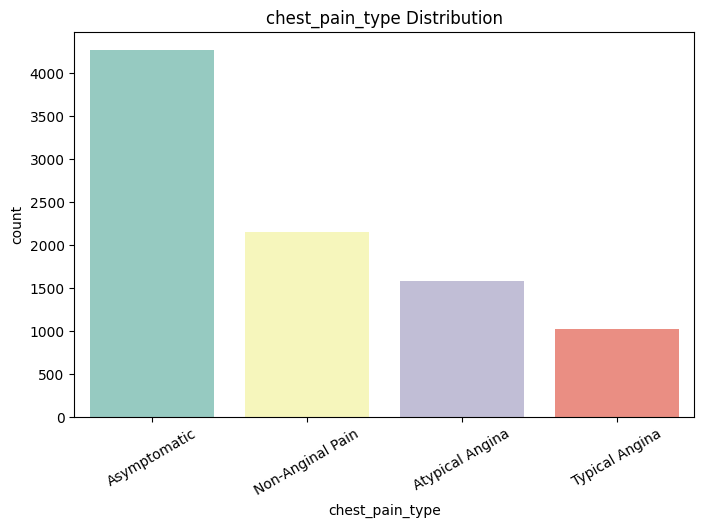

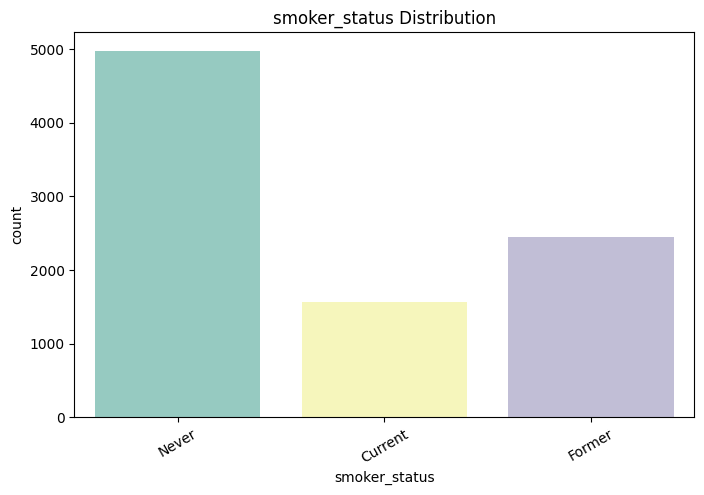

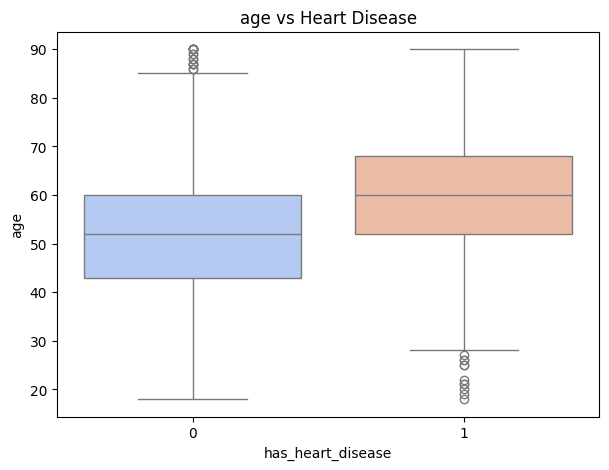

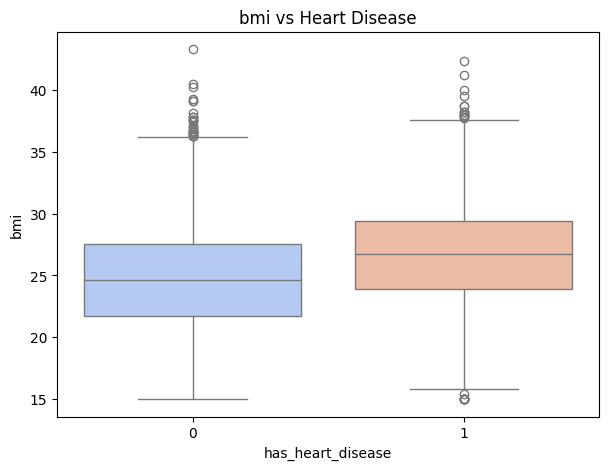

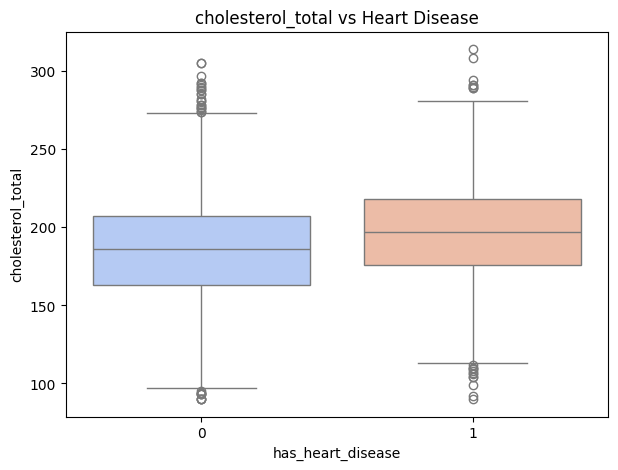

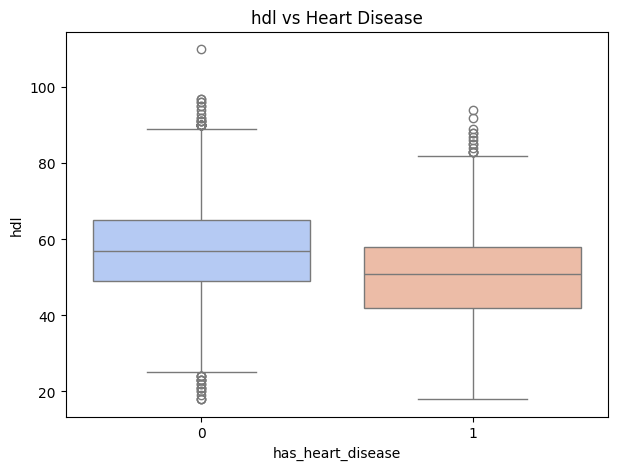

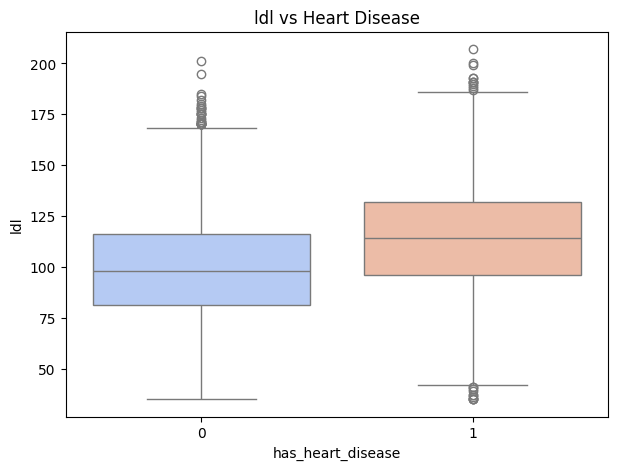

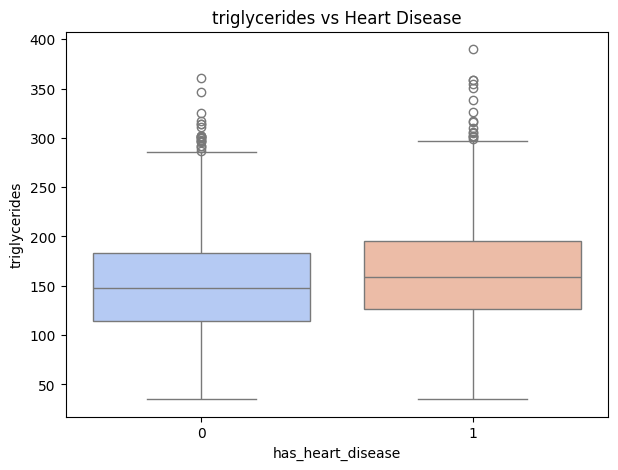

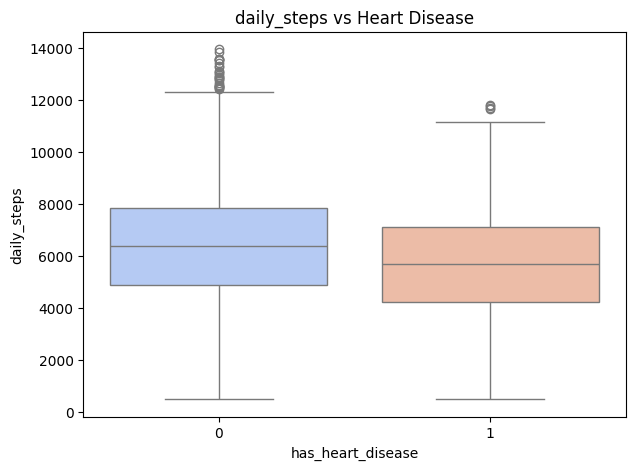

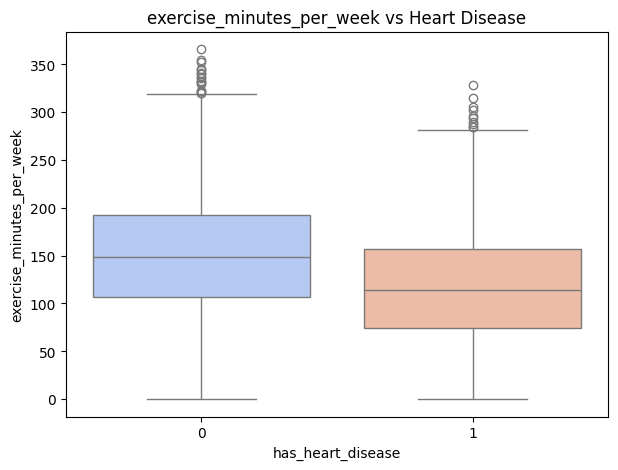

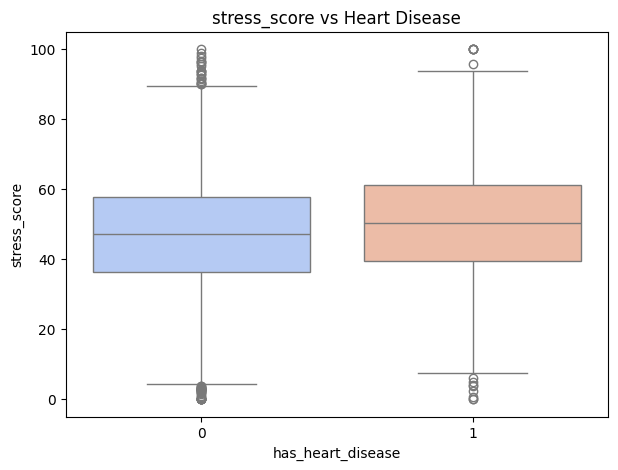

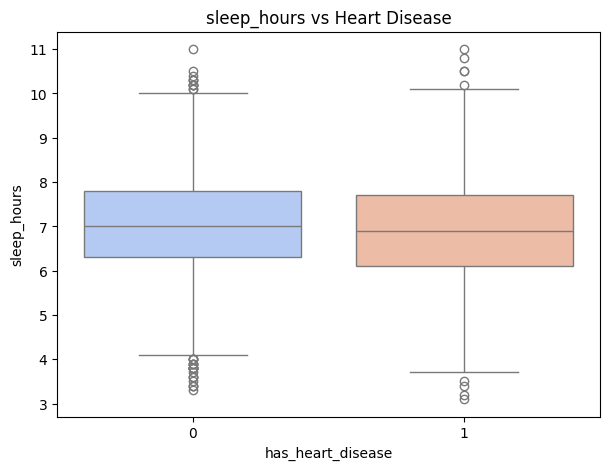

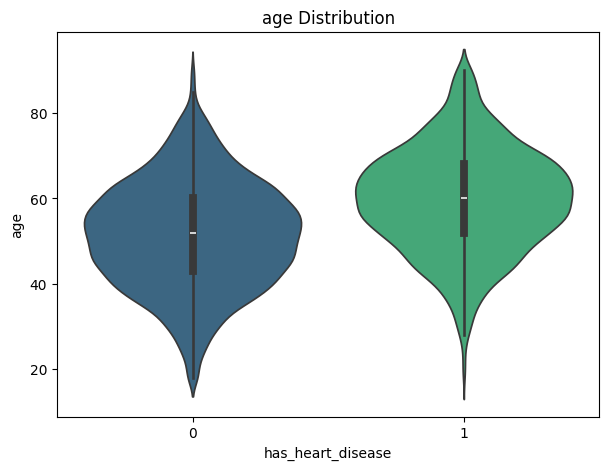

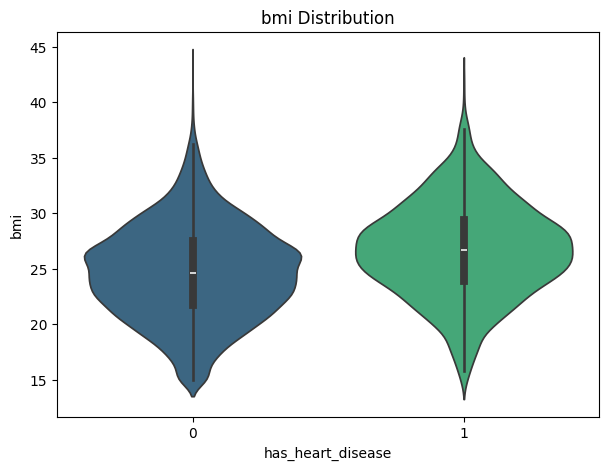

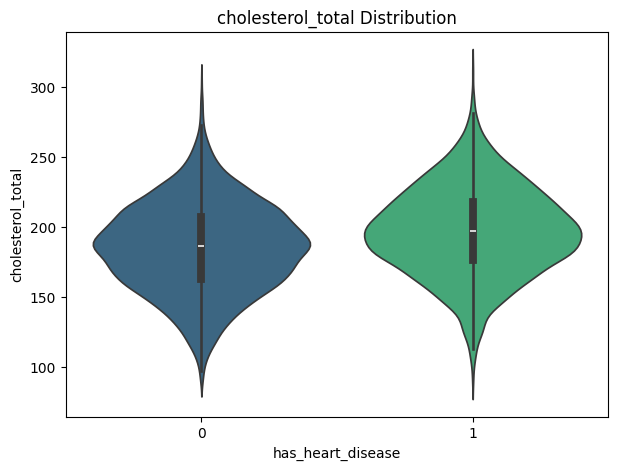

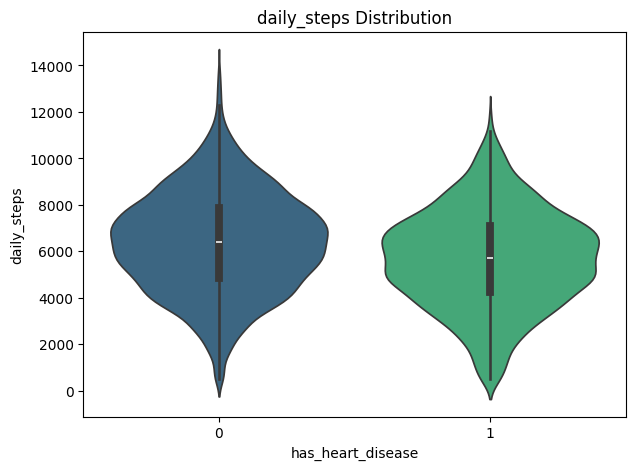

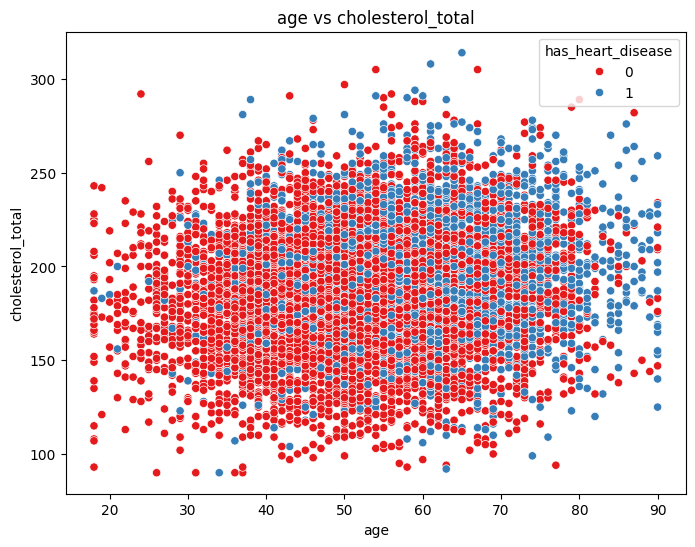

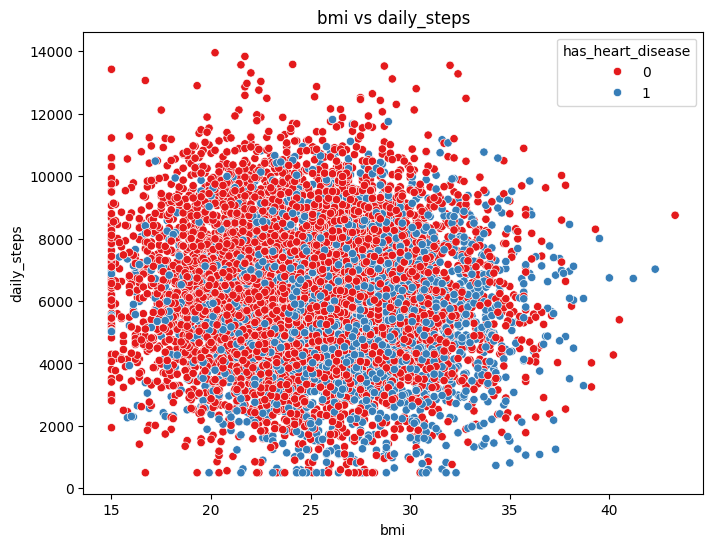

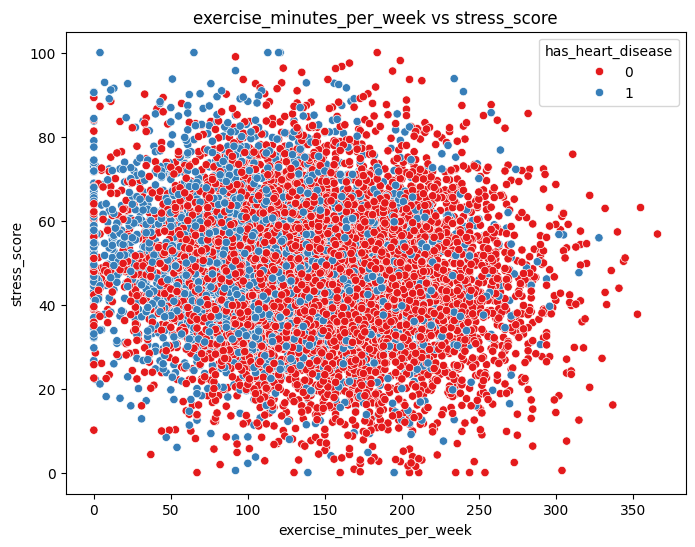

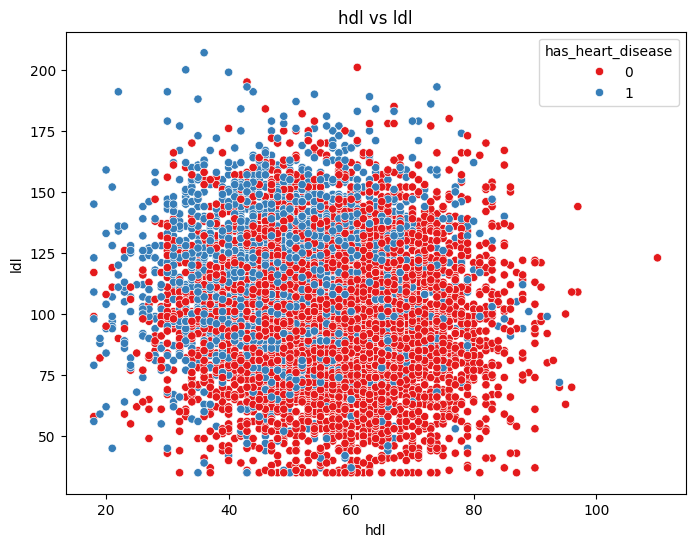

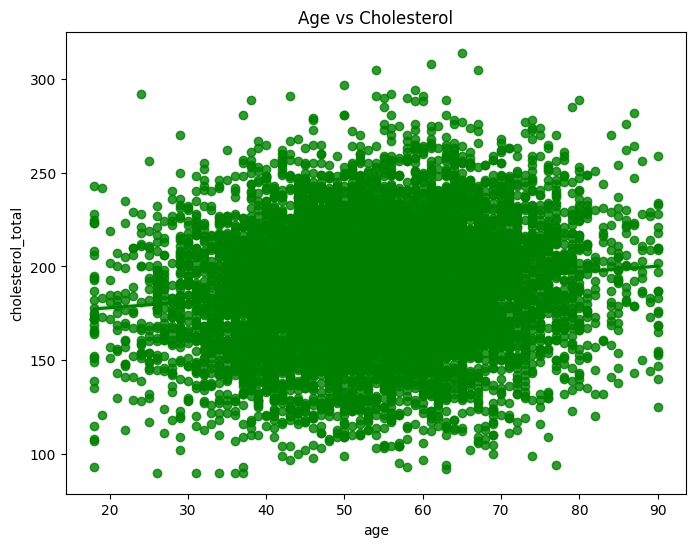

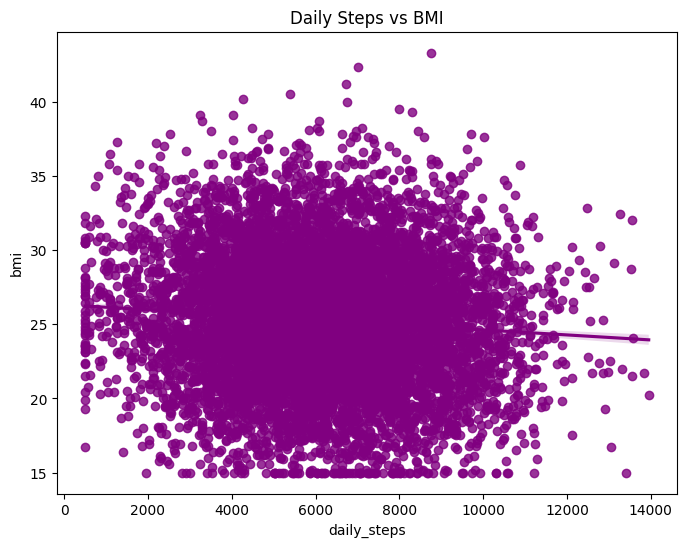

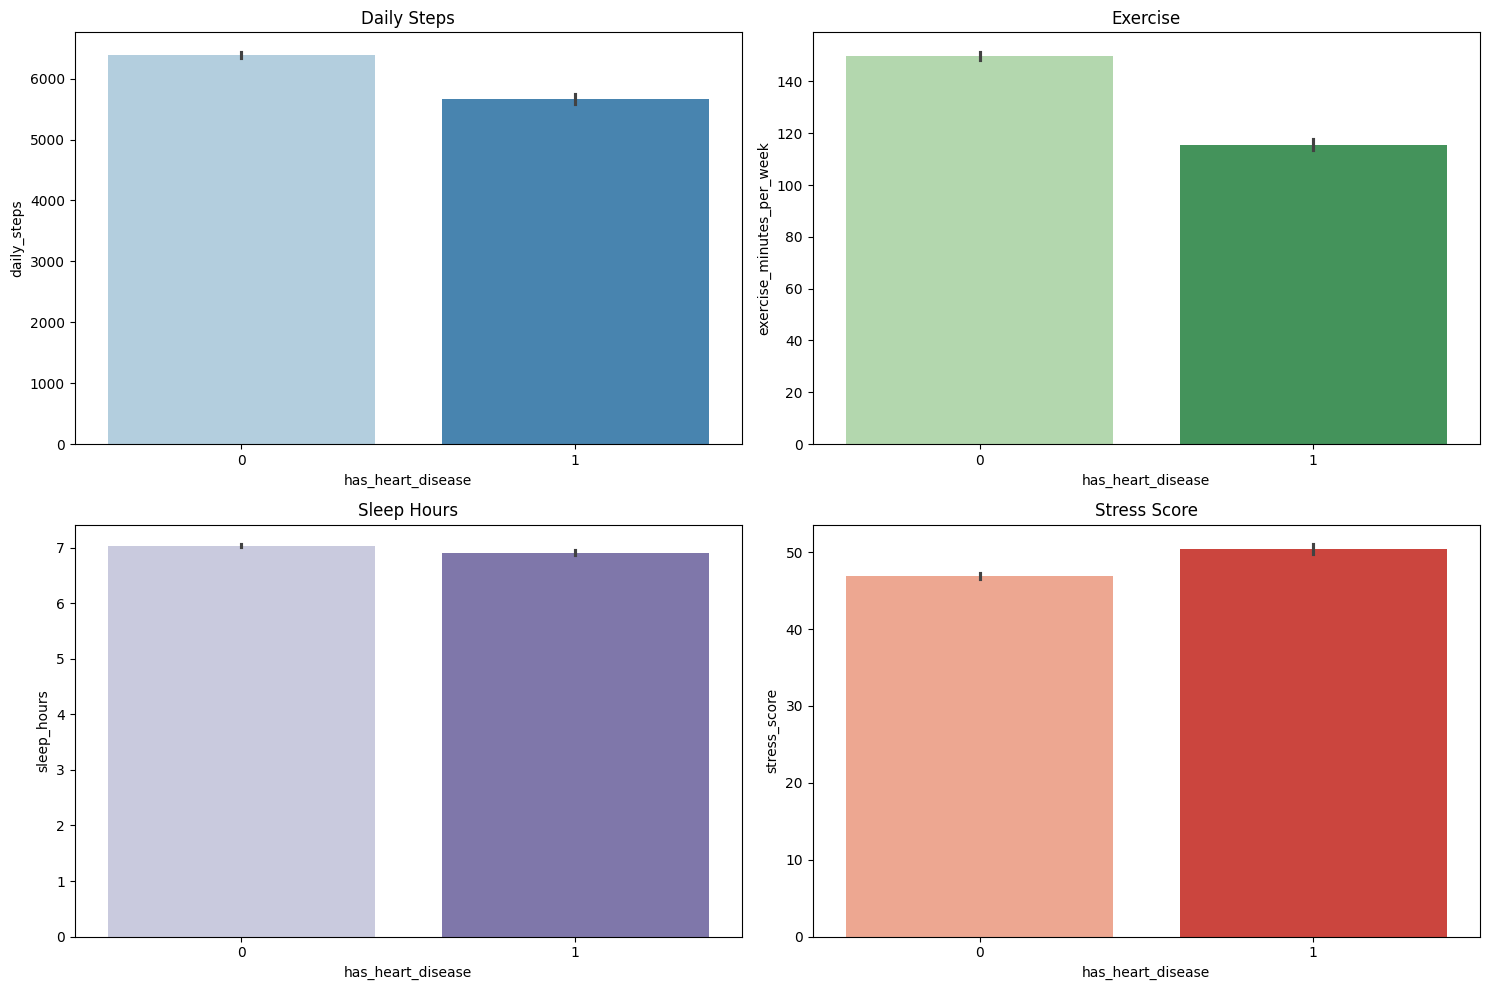

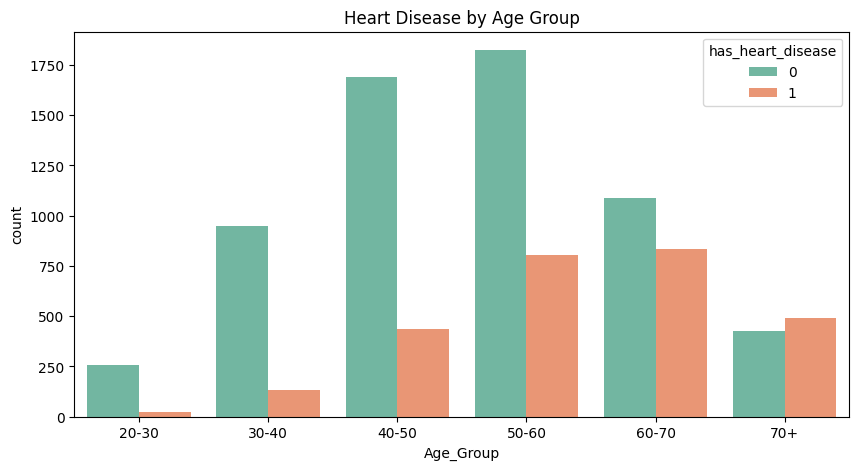

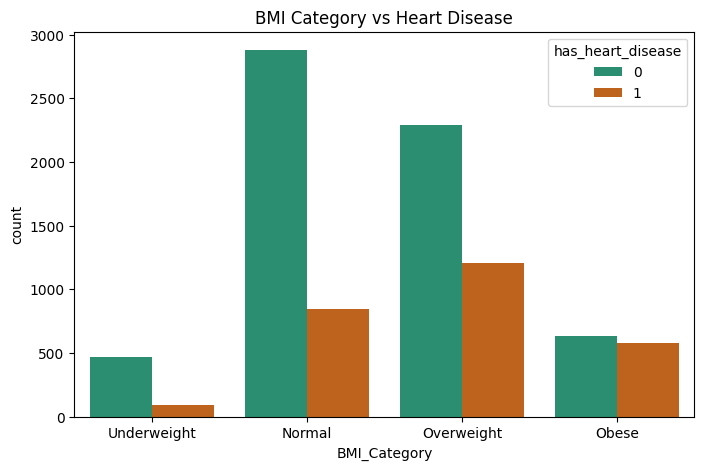

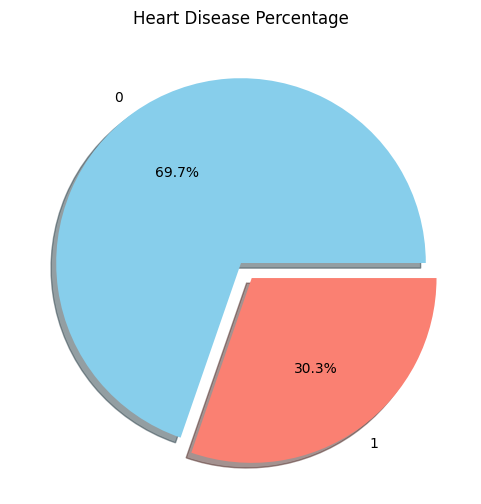

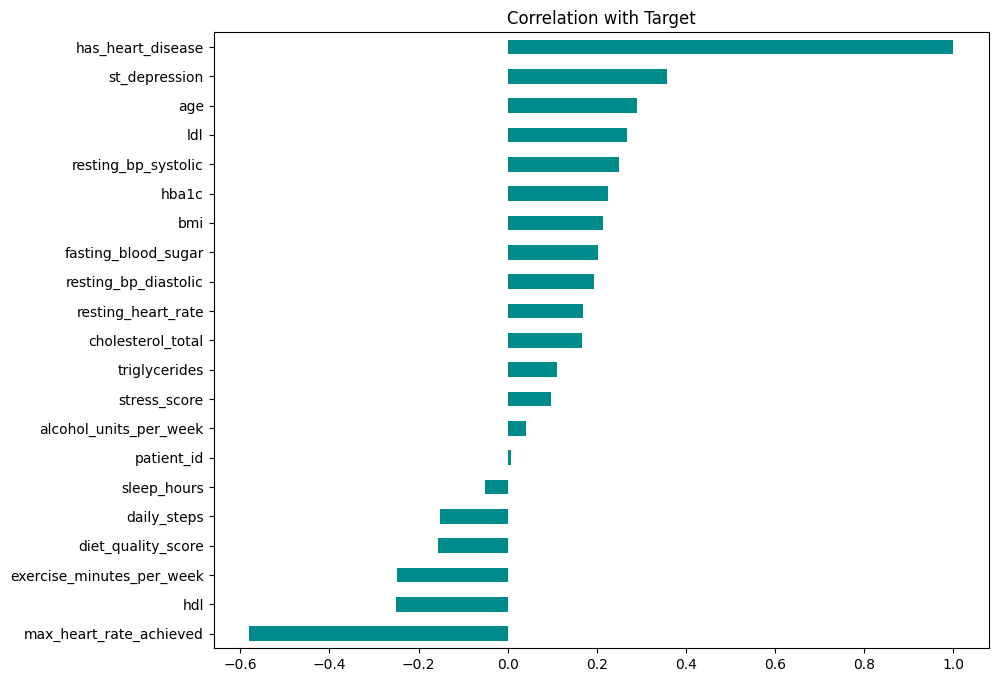

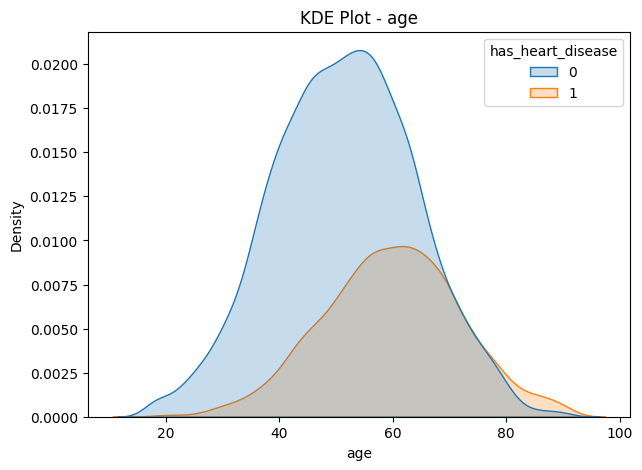

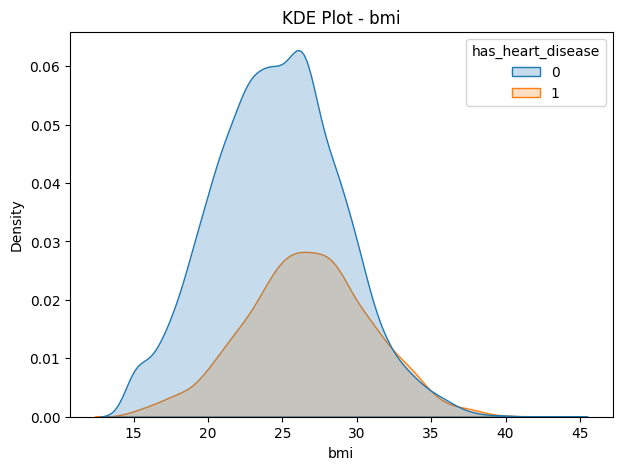

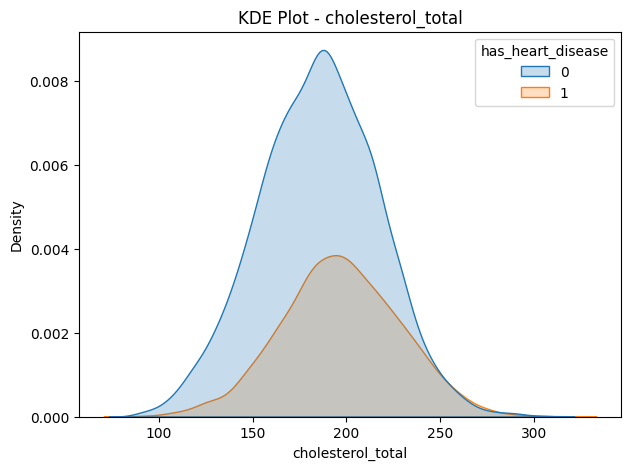

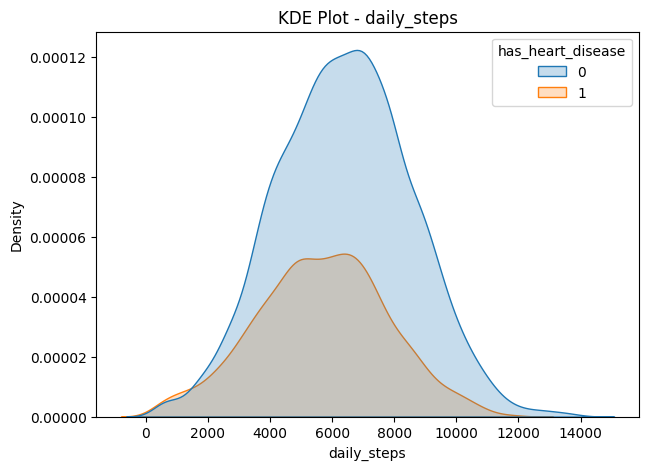

EDA Visualization Completed Successfully


In [14]:
#-----------------------------------------------------------
# Basic Information
#-----------------------------------------------------------

print(df.info())

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Rows :",df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe().T)

#===========================================================
# Numerical and Categorical Columns
#===========================================================

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include=['object','category']).columns.tolist()

print(numerical_columns)
print(categorical_columns)

#===========================================================
# Missing Value Visualization
#===========================================================

plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values Heatmap",
          fontsize=18,
          weight='bold')

plt.show()

#===========================================================
# Target Variable Distribution
#===========================================================

plt.figure(figsize=(6,5))

colors=['royalblue','crimson']

sns.countplot(data=df,
              x='has_heart_disease',
              palette=colors)

plt.title("Target Variable Distribution",
          fontsize=16,
          weight='bold')

plt.xlabel("Heart Disease")

plt.ylabel("Count")

plt.show()

#===========================================================
# Numerical Feature Distribution
#===========================================================

for col in numerical_columns:

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)

    sns.histplot(df[col],
                 kde=True,
                 color="teal",
                 bins=30)

    plt.title(f"Histogram of {col}")

    plt.subplot(1,2,2)

    sns.boxplot(x=df[col],
                color="orange")

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()

    plt.show()

#===========================================================
# Correlation Heatmap
#===========================================================

plt.figure(figsize=(18,12))

corr=df[numerical_columns].corr()

sns.heatmap(corr,
            annot=True,
            cmap="RdYlBu",
            fmt=".2f")

plt.title("Correlation Heatmap",
          fontsize=18,
          weight='bold')

plt.show()

#===========================================================
# Pairplot
#===========================================================

pair_features=[
    'age',
    'cholesterol_total',
    'bmi',
    'daily_steps',
    'exercise_minutes_per_week',
    'stress_score',
    'has_heart_disease'
]

sns.pairplot(df[pair_features],
             hue='has_heart_disease',
             palette="Set2")

plt.show()

#===========================================================
# Countplots of Categorical Variables
#===========================================================

for col in categorical_columns:

    plt.figure(figsize=(8,5))

    sns.countplot(data=df,
                  x=col,
                  palette="Set3")

    plt.title(f"{col} Distribution")

    plt.xticks(rotation=30)

    plt.show()

#===========================================================
# Boxplots against Target
#===========================================================

important_features=[

'age',
'bmi',
'cholesterol_total',
'hdl',
'ldl',
'triglycerides',
'daily_steps',
'exercise_minutes_per_week',
'stress_score',
'sleep_hours'

]

for col in important_features:

    plt.figure(figsize=(7,5))

    sns.boxplot(data=df,
                x='has_heart_disease',
                y=col,
                palette="coolwarm")

    plt.title(f"{col} vs Heart Disease")

    plt.show()

#===========================================================
# Violin Plots
#===========================================================

for col in ['age',
            'bmi',
            'cholesterol_total',
            'daily_steps']:

    plt.figure(figsize=(7,5))

    sns.violinplot(data=df,
                   x='has_heart_disease',
                   y=col,
                   palette="viridis")

    plt.title(f"{col} Distribution")

    plt.show()

#===========================================================
# Scatterplots
#===========================================================

scatter_features=[

('age','cholesterol_total'),

('bmi','daily_steps'),

('exercise_minutes_per_week','stress_score'),

('hdl','ldl')

]

for x,y in scatter_features:

    plt.figure(figsize=(8,6))

    sns.scatterplot(data=df,
                    x=x,
                    y=y,
                    hue='has_heart_disease',
                    palette="Set1")

    plt.title(f"{x} vs {y}")

    plt.show()

#===========================================================
# Regression Plots
#===========================================================

plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='age',
            y='cholesterol_total',
            color='green')

plt.title("Age vs Cholesterol")

plt.show()

plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='daily_steps',
            y='bmi',
            color='purple')

plt.title("Daily Steps vs BMI")

plt.show()

#===========================================================
# Lifestyle Analysis
#===========================================================

fig,ax=plt.subplots(2,2,
                    figsize=(15,10))

sns.barplot(data=df,
            x='has_heart_disease',
            y='daily_steps',
            palette="Blues",
            ax=ax[0,0])

ax[0,0].set_title("Daily Steps")

sns.barplot(data=df,
            x='has_heart_disease',
            y='exercise_minutes_per_week',
            palette="Greens",
            ax=ax[0,1])

ax[0,1].set_title("Exercise")

sns.barplot(data=df,
            x='has_heart_disease',
            y='sleep_hours',
            palette="Purples",
            ax=ax[1,0])

ax[1,0].set_title("Sleep Hours")

sns.barplot(data=df,
            x='has_heart_disease',
            y='stress_score',
            palette="Reds",
            ax=ax[1,1])

ax[1,1].set_title("Stress Score")

plt.tight_layout()

plt.show()

#===========================================================
# Age Groups
#===========================================================

bins=[20,30,40,50,60,70,90]

labels=['20-30','30-40','40-50','50-60','60-70','70+']

df['Age_Group']=pd.cut(df['age'],
                       bins=bins,
                       labels=labels)

plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x='Age_Group',
              hue='has_heart_disease',
              palette="Set2")

plt.title("Heart Disease by Age Group")

plt.show()

#===========================================================
# BMI Categories
#===========================================================

bmi_bins=[0,18.5,25,30,100]

bmi_labels=['Underweight',
            'Normal',
            'Overweight',
            'Obese']

df['BMI_Category']=pd.cut(df['bmi'],
                          bins=bmi_bins,
                          labels=bmi_labels)

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='BMI_Category',
              hue='has_heart_disease',
              palette="Dark2")

plt.title("BMI Category vs Heart Disease")

plt.show()

#===========================================================
# Heart Disease Percentage
#===========================================================

heart=df['has_heart_disease'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(heart.values,
        labels=heart.index,
        autopct='%1.1f%%',
        colors=['skyblue','salmon'],
        explode=[0,0.1],
        shadow=True)

plt.title("Heart Disease Percentage")

plt.show()

#===========================================================
# Correlation with Target
#===========================================================

corr_target=df[numerical_columns].corr()['has_heart_disease'].sort_values()

plt.figure(figsize=(10,8))

corr_target.plot(kind='barh',
                 color='darkcyan')

plt.title("Correlation with Target")

plt.show()

#===========================================================
# KDE Plots
#===========================================================

for col in ['age',
            'bmi',
            'cholesterol_total',
            'daily_steps']:

    plt.figure(figsize=(7,5))

    sns.kdeplot(data=df,
                x=col,
                hue='has_heart_disease',
                fill=True)

    plt.title(f"KDE Plot - {col}")

    plt.show()

print("="*60)
print("EDA Visualization Completed Successfully")
print("="*60)

## Feature engineering

Training samples: 7200 Testing samples: 1800
Accuracy on test set: 0.885


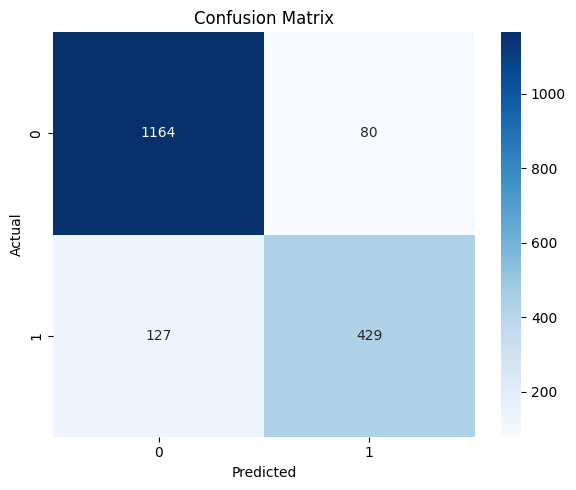

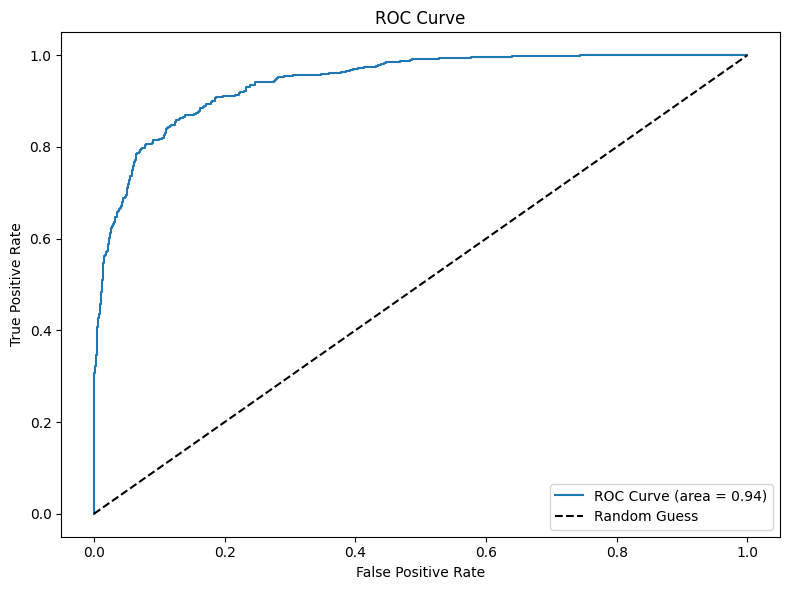

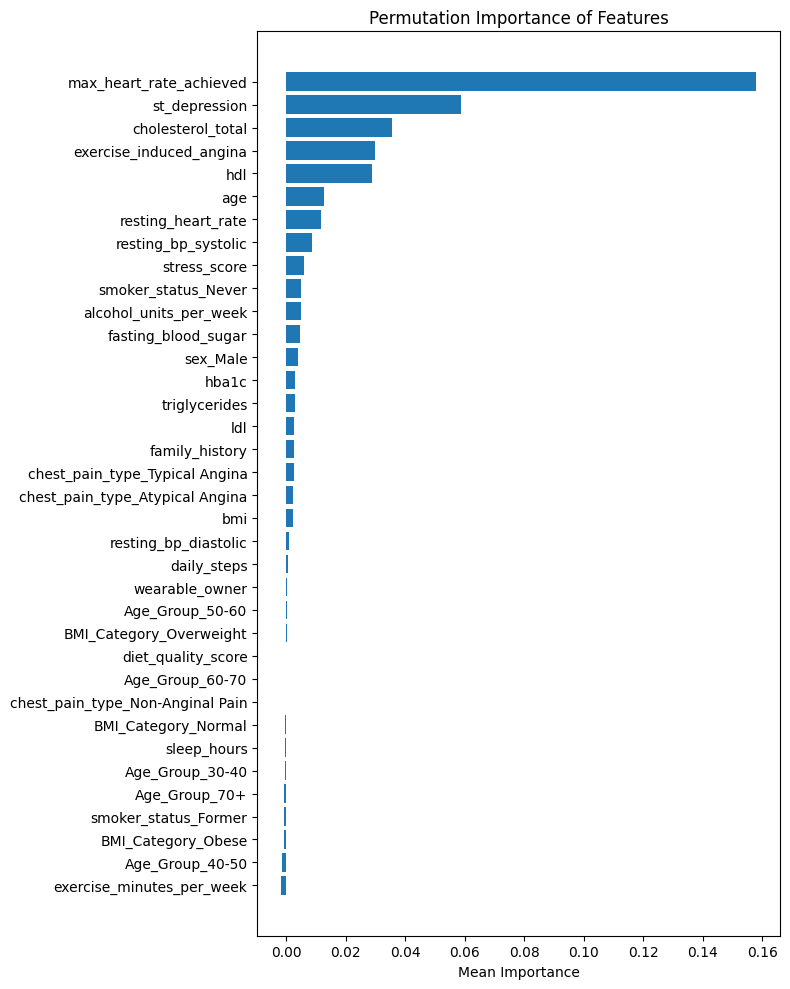

In [15]:
# Define feature set and target variable
X = df.drop(['patient_id', 'has_heart_disease'], axis=1)  
# For simplicity, let's perform one-hot encoding on categorical features
X = pd.get_dummies(X, drop_first=True)
y = df['has_heart_disease']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training samples:', X_train.shape[0], 'Testing samples:', X_test.shape[0])

# Initialize and fit Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy on test set:', accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
feature_names = X_test.columns
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(8, 10))
plt.barh(feature_names[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel('Mean Importance')
plt.title('Permutation Importance of Features')
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!!